# Week 03 — Capstone BBO Experiments

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys

sys.path.append("../src")

# ML imports
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
from sklearn.model_selection import LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.spatial.distance import cdist

warnings.filterwarnings("ignore", message="R.*score is not well-defined")

# Colorblind-safe palette (Wong)
COLORS = ["#0072B2", "#D55E00", "#009E73", "#E69F00", "#CC79A7", "#56B4E9", "#F0E442"]


In [2]:
def load_function(n):
    X = np.load(f"../data/function_{n}/initial_inputs.npy")
    Y = np.load(f"../data/function_{n}/initial_outputs.npy")
    print(f"Function {n}: {X.shape[0]} points, {X.shape[1]}D, best y = {Y.max():.4f}")
    return X, Y


## Function 1

In [3]:
# Function 1 — Data overview
X, Y = load_function(1)
n_pts = len(Y)
best_idx = np.argmax(Y)

print(f"F1: {n_pts} points, {X.shape[1]}D")
print(f"Best Y: {Y.max():.4e} at pt{best_idx + 1} ({X[best_idx]})")
print(f"Worst Y: {Y.min():.4e} at pt{np.argmin(Y) + 1}")
print(f"Y std (baseline RMSE): {Y.std():.4e}")
print()

# Classify by sign
neg_mask = Y < -1e-10
print(f"Positive/zero: {(~neg_mask).sum()} pts | Negative: {neg_mask.sum()} pts")
print()

# Week 02 result check
print("Week 02 query: pt12 at (0.78, 0.78)")
print(
    f"  Result: Y = {Y[11]:.4e} — {'improved' if Y[11] > Y[best_idx] else 'did NOT improve'}"
)
print(f"  Suggestion was: if Y ~0 again → switch to exploration")
print()

# Data table sorted by Y
order = np.argsort(Y)[::-1]
print(f"{'Pt':>4} {'x1':>8} {'x2':>8} {'Y':>14} {'log10|Y|':>10} {'Sign':>6}")
print("-" * 55)
for i in order:
    log_y = np.log10(np.abs(Y[i]) + 1e-200)
    sign = "+" if Y[i] >= 0 else "-"
    print(
        f"pt{i + 1:>2} {X[i, 0]:>8.4f} {X[i, 1]:>8.4f} {Y[i]:>14.4e} {log_y:>10.1f} {sign:>6}"
    )

Function 1: 12 points, 2D, best y = 0.0000
F1: 12 points, 2D
Best Y: 7.7109e-16 at pt3 ([0.73102363 0.73299988])
Worst Y: -6.6274e-03 at pt11
Y std (baseline RMSE): 2.0041e-03

Positive/zero: 10 pts | Negative: 2 pts

Week 02 query: pt12 at (0.78, 0.78)
  Result: Y = 2.5001e-32 — did NOT improve
  Suggestion was: if Y ~0 again → switch to exploration

  Pt       x1       x2              Y   log10|Y|   Sign
-------------------------------------------------------
pt 3   0.7310   0.7330     7.7109e-16      -15.1      +
pt12   0.7800   0.7800     2.5001e-32      -31.6      +
pt 8   0.6834   0.8611     2.5350e-40      -39.6      +
pt 2   0.5743   0.8799     1.0331e-46      -46.0      +
pt10   0.8839   0.5823     6.2299e-48      -47.2      +
pt 1   0.3194   0.7630     1.3227e-79      -78.9      +
pt 9   0.0825   0.4035     3.6068e-81      -80.4      +
pt 4   0.8404   0.2647    3.3418e-124     -123.5      +
pt 7   0.3127   0.0787    -2.0891e-91      -90.7      -
pt 6   0.4104   0.1476    -2.1

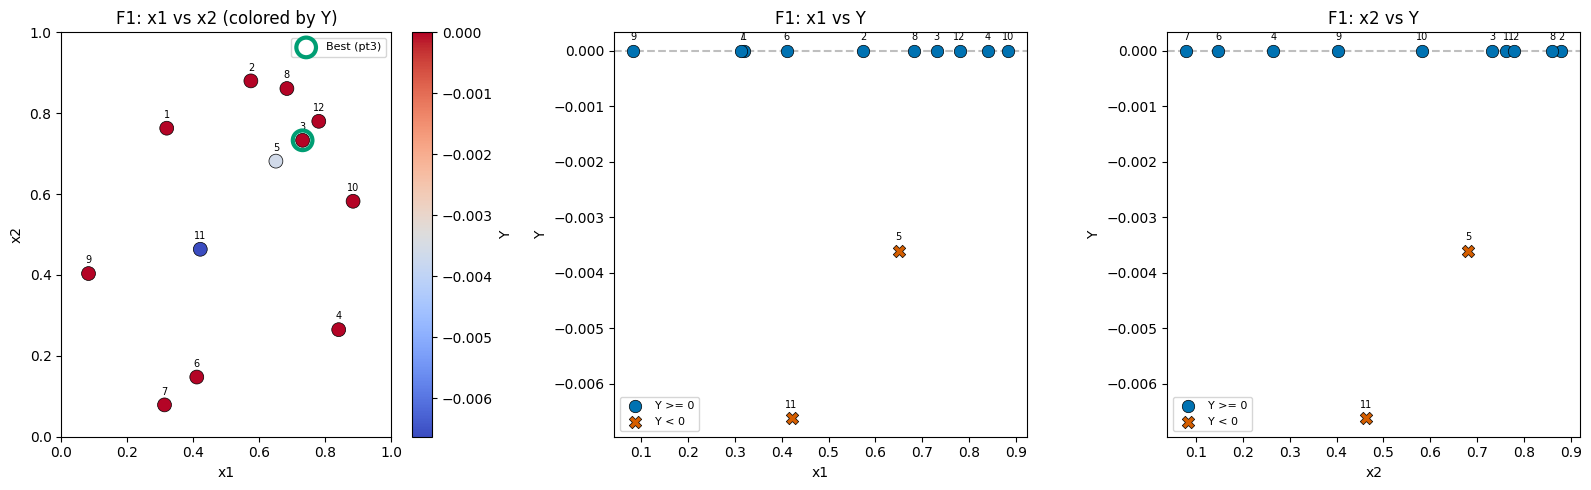

In [4]:
# F1 — Scatter plots: x1 vs x2, x1 vs Y, x2 vs Y
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# x1 vs x2 colored by Y
ax = axes[0]
sc = ax.scatter(
    X[:, 0],
    X[:, 1],
    c=Y,
    cmap="coolwarm",
    s=100,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
)
ax.scatter(
    X[best_idx, 0],
    X[best_idx, 1],
    c="none",
    edgecolors=COLORS[2],
    s=200,
    linewidth=3,
    zorder=6,
    label=f"Best (pt{best_idx + 1})",
)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], X[i, 1]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
    )
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("F1: x1 vs x2 (colored by Y)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label="Y")

# x1 vs Y
ax = axes[1]
pos_mask = Y >= -1e-10
ax.scatter(
    X[pos_mask, 0],
    Y[pos_mask],
    c=COLORS[0],
    s=80,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
    label="Y >= 0",
)
ax.scatter(
    X[neg_mask, 0],
    Y[neg_mask],
    c=COLORS[1],
    s=80,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
    marker="X",
    label="Y < 0",
)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], Y[i]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
    )
ax.set_xlabel("x1")
ax.set_ylabel("Y")
ax.set_title("F1: x1 vs Y")
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.legend(fontsize=8)

# x2 vs Y
ax = axes[2]
ax.scatter(
    X[pos_mask, 1],
    Y[pos_mask],
    c=COLORS[0],
    s=80,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
    label="Y >= 0",
)
ax.scatter(
    X[neg_mask, 1],
    Y[neg_mask],
    c=COLORS[1],
    s=80,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
    marker="X",
    label="Y < 0",
)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 1], Y[i]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
    )
ax.set_xlabel("x2")
ax.set_ylabel("Y")
ax.set_title("F1: x2 vs Y")
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    "../plots/week_03/function_1_scatter_plots.png", dpi=150, bbox_inches="tight"
)
plt.show()

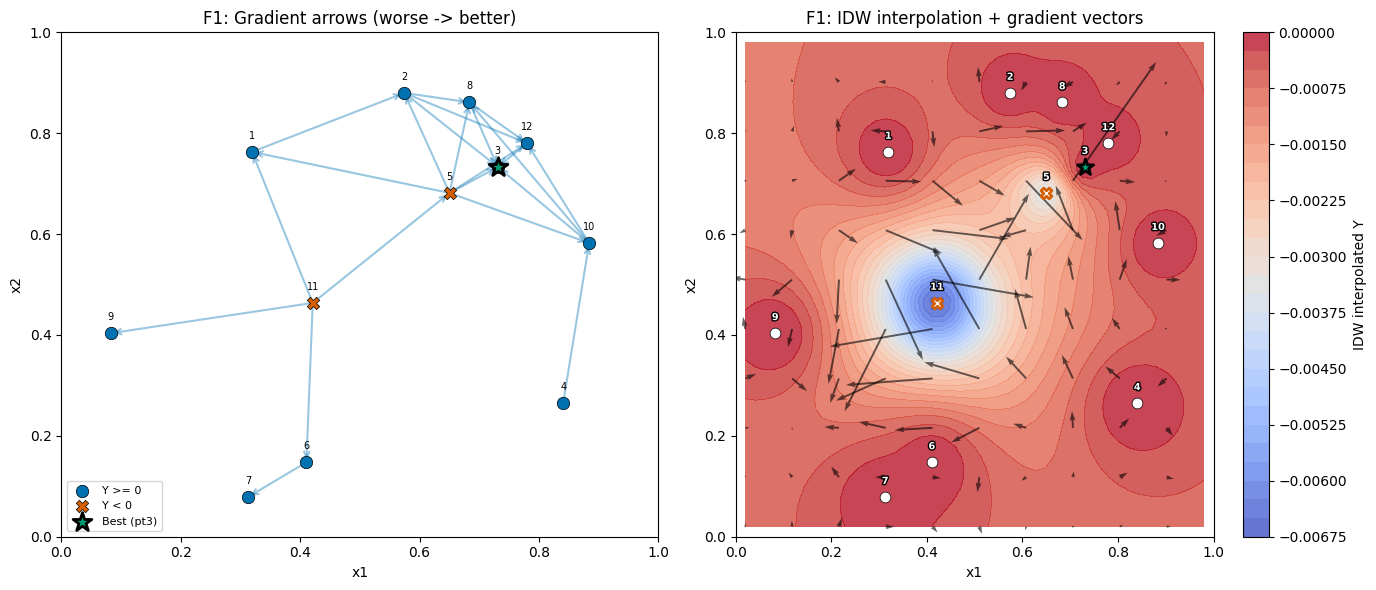

In [5]:
# F1 — Gradient map: arrows between nearby points + IDW interpolation with gradient vectors
import matplotlib.patheffects as pe

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Arrow plot (worse → better between nearby pairs) ---
ax = axes[0]
D_matrix = cdist(X, X)
threshold = 0.35

for i in range(n_pts):
    for j in range(i + 1, n_pts):
        if D_matrix[i, j] < threshold:
            src, dst = (j, i) if Y[i] > Y[j] else (i, j)
            ax.annotate(
                "",
                xy=(X[dst, 0], X[dst, 1]),
                xytext=(X[src, 0], X[src, 1]),
                arrowprops=dict(arrowstyle="->", color=COLORS[0], alpha=0.4, lw=1.5),
            )

ax.scatter(
    X[pos_mask, 0],
    X[pos_mask, 1],
    c=COLORS[0],
    s=80,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
    marker="o",
    label="Y >= 0",
)
ax.scatter(
    X[neg_mask, 0],
    X[neg_mask, 1],
    c=COLORS[1],
    s=80,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
    marker="X",
    label="Y < 0",
)
ax.scatter(
    X[best_idx, 0],
    X[best_idx, 1],
    c=COLORS[2],
    s=200,
    edgecolors="black",
    linewidth=2,
    zorder=6,
    marker="*",
    label=f"Best (pt{best_idx + 1})",
)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], X[i, 1]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 8),
        textcoords="offset points",
    )
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("F1: Gradient arrows (worse -> better)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=8, loc="lower left")

# --- Right: IDW interpolation heatmap + gradient vectors ---
ax = axes[1]
grid_n = 50
xx, yy = np.meshgrid(np.linspace(0.02, 0.98, grid_n), np.linspace(0.02, 0.98, grid_n))
grid_pts = np.column_stack([xx.ravel(), yy.ravel()])

# IDW interpolation
D_grid = cdist(grid_pts, X)
D_grid = np.maximum(D_grid, 1e-10)
weights = 1.0 / D_grid**2
weights /= weights.sum(axis=1, keepdims=True)
Z_idw = (weights @ Y).reshape(grid_n, grid_n)

# Numerical gradient of interpolated surface
dy_dx1, dy_dx2 = np.gradient(Z_idw, 0.98 / grid_n, 0.98 / grid_n)

im = ax.contourf(xx, yy, Z_idw, levels=30, cmap="coolwarm", alpha=0.8)
plt.colorbar(im, ax=ax, label="IDW interpolated Y")

skip = 5
ax.quiver(
    xx[::skip, ::skip],
    yy[::skip, ::skip],
    dy_dx1[::skip, ::skip],
    dy_dx2[::skip, ::skip],
    color="black",
    alpha=0.6,
    scale=0.15,
    width=0.004,
)

ax.scatter(
    X[pos_mask, 0],
    X[pos_mask, 1],
    c="white",
    s=60,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
)
ax.scatter(
    X[neg_mask, 0],
    X[neg_mask, 1],
    c="white",
    s=60,
    edgecolors=COLORS[1],
    linewidth=2,
    zorder=5,
    marker="X",
)
ax.scatter(
    X[best_idx, 0],
    X[best_idx, 1],
    c=COLORS[2],
    s=150,
    edgecolors="black",
    linewidth=2,
    zorder=6,
    marker="*",
)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], X[i, 1]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 8),
        textcoords="offset points",
        color="white",
        fontweight="bold",
        path_effects=[pe.withStroke(linewidth=2, foreground="black")],
    )

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("F1: IDW interpolation + gradient vectors")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(
    "../plots/week_03/function_1_gradient_map.png", dpi=150, bbox_inches="tight"
)
plt.show()

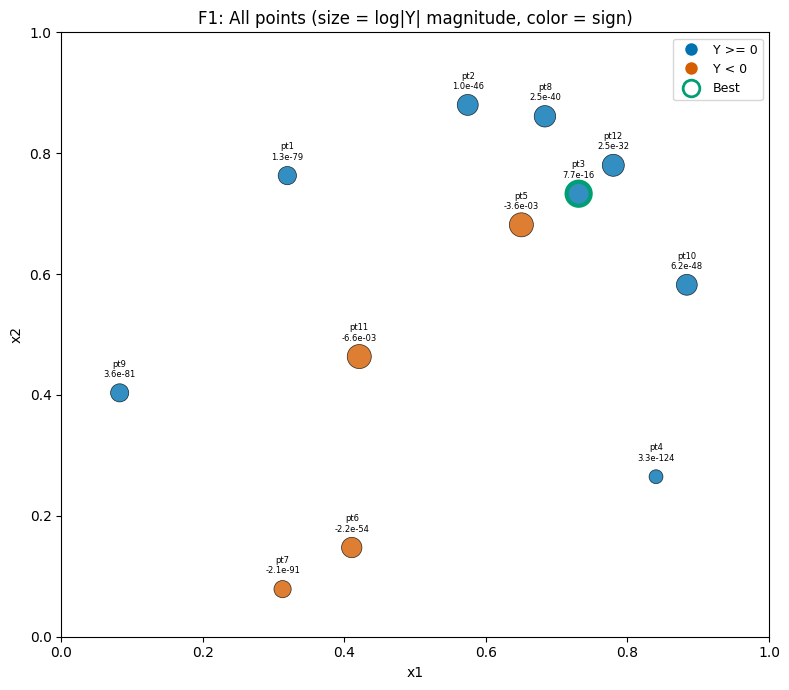


Sharp feature: pt3 and pt5 are only 0.0959 apart
  pt3: (0.7310, 0.7330) Y = 7.71e-16
  pt5: (0.6501, 0.6815) Y = -3.61e-03
  Direction pt5 -> pt3: dx1=0.0809, dx2=0.0515
  Massive Y change over tiny distance — very sharp feature


In [6]:
# F1 — Log-scale spatial map (since Y values span 100+ orders of magnitude)
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

log_abs_Y = np.log10(np.abs(Y) + 1e-200)
colors_pts = [COLORS[0] if y >= 0 else COLORS[1] for y in Y]
# Size proportional to log|Y| (larger = stronger signal)
sizes = 100 + 200 * (log_abs_Y - log_abs_Y.min()) / (log_abs_Y.max() - log_abs_Y.min())

ax.scatter(
    X[:, 0],
    X[:, 1],
    c=colors_pts,
    s=sizes,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
    alpha=0.8,
)
ax.scatter(
    X[best_idx, 0],
    X[best_idx, 1],
    c="none",
    edgecolors=COLORS[2],
    s=300,
    linewidth=3,
    zorder=6,
)

for i in range(n_pts):
    label = f"pt{i + 1}\n{Y[i]:.1e}"
    ax.annotate(
        label,
        (X[i, 0], X[i, 1]),
        fontsize=6,
        ha="center",
        va="bottom",
        xytext=(0, 10),
        textcoords="offset points",
    )

from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=COLORS[0],
        markersize=10,
        label="Y >= 0",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=COLORS[1],
        markersize=10,
        label="Y < 0",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="none",
        markeredgecolor=COLORS[2],
        markersize=12,
        markeredgewidth=2,
        label="Best",
    ),
]
ax.legend(handles=legend_elements, fontsize=9)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("F1: All points (size = log|Y| magnitude, color = sign)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("../plots/week_03/function_1_log_scale.png", dpi=150, bbox_inches="tight")
plt.show()

# Sharp feature analysis
dist_3_5 = np.linalg.norm(X[2] - X[4])
direction = X[2] - X[4]
print(f"\nSharp feature: pt3 and pt5 are only {dist_3_5:.4f} apart")
print(f"  pt3: ({X[2, 0]:.4f}, {X[2, 1]:.4f}) Y = {Y[2]:.2e}")
print(f"  pt5: ({X[4, 0]:.4f}, {X[4, 1]:.4f}) Y = {Y[4]:.2e}")
print(f"  Direction pt5 -> pt3: dx1={direction[0]:.4f}, dx2={direction[1]:.4f}")
print(f"  Massive Y change over tiny distance — very sharp feature")

In [7]:
# F1 — GridSearchCV model fitting (raw Y)
loo = LeaveOneOut()
baseline_rmse = Y.std()
print(f"Baseline RMSE (Y.std): {baseline_rmse:.4e}\n")

results_f1 = []

# Ridge
grid = GridSearchCV(
    Ridge(),
    {"alpha": [0.01, 0.1, 1.0, 10, 100]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
)
grid.fit(X, Y)
rmse = np.sqrt(-grid.best_score_)
results_f1.append(("Ridge", grid.best_params_, rmse, grid))

# KNN
grid = GridSearchCV(
    KNeighborsRegressor(),
    {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
)
grid.fit(X, Y)
rmse = np.sqrt(-grid.best_score_)
results_f1.append(("KNN", grid.best_params_, rmse, grid))

# Random Forest
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
)
grid.fit(X, Y)
rmse = np.sqrt(-grid.best_score_)
results_f1.append(("RF", grid.best_params_, rmse, grid))

# SVR
grid = GridSearchCV(
    SVR(),
    {"C": [0.1, 1, 10, 100], "kernel": ["rbf"], "gamma": ["scale", "auto"]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
)
grid.fit(X, Y)
rmse = np.sqrt(-grid.best_score_)
results_f1.append(("SVR", grid.best_params_, rmse, grid))

# Gradient Boosting
grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {"max_depth": [2, 3], "n_estimators": [50, 100], "learning_rate": [0.01, 0.1, 0.3]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
)
grid.fit(X, Y)
rmse = np.sqrt(-grid.best_score_)
results_f1.append(("GB", grid.best_params_, rmse, grid))

# Gaussian Process (Matern)
gp_matern = GaussianProcessRegressor(
    kernel=Matern(nu=2.5), random_state=42, n_restarts_optimizer=5
)
scores = cross_val_score(gp_matern, X, Y, cv=loo, scoring="neg_mean_squared_error")
rmse_gp = np.sqrt(-scores.mean())
results_f1.append(("GP-Matern", {}, rmse_gp, None))

# Results table
print(f"{'Model':<15} {'RMSE':>12} {'Improvement':>12} {'Beats?':>8} {'Best Params'}")
print("-" * 75)
for name, params, rmse, _ in sorted(results_f1, key=lambda x: x[2]):
    imp = (1 - rmse / baseline_rmse) * 100
    beats = "YES" if imp > 0 else "no"
    p_str = str(params) if params else ""
    print(f"{name:<15} {rmse:>12.4e} {imp:>11.1f}% {beats:>8}  {p_str}")

n_beating = sum(1 for _, _, rmse, _ in results_f1 if rmse < baseline_rmse)
print(f"\n{'=' * 60}")
print(f"Models beating baseline: {n_beating}/{len(results_f1)}")
if n_beating == 0:
    print("NO model beats baseline on raw Y — data is too flat/sparse for regression")

Baseline RMSE (Y.std): 2.0041e-03

Model                   RMSE  Improvement   Beats? Best Params
---------------------------------------------------------------------------
Ridge             2.1872e-03        -9.1%       no  {'alpha': 100}
KNN               2.2680e-03       -13.2%       no  {'n_neighbors': 7, 'weights': 'distance'}
GB                2.4129e-03       -20.4%       no  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
RF                2.5995e-03       -29.7%       no  {'max_depth': 3, 'n_estimators': 200}
GP-Matern         3.1168e-03       -55.5%       no  
SVR               3.3312e-03       -66.2%       no  {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}

Models beating baseline: 0/6
NO model beats baseline on raw Y — data is too flat/sparse for regression


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 6 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


In [8]:
# F1 — Log-transformed model fitting (log10|Y| as target)
# Rationale: Y values span ~120 orders of magnitude. Log-transform spreads them
# out so models can learn spatial structure (which regions have stronger signal).
log_abs_Y = np.log10(np.abs(Y) + 1e-200)
baseline_log = log_abs_Y.std()

print(f"log10|Y| range: [{log_abs_Y.min():.1f}, {log_abs_Y.max():.1f}]")
print(f"log10|Y| std (baseline): {baseline_log:.2f}\n")

results_log = []

# SVR on log|Y| — best performer from preliminary testing
grid = GridSearchCV(
    SVR(),
    {"C": [0.1, 1, 10, 100], "kernel": ["rbf"], "gamma": ["scale", "auto"]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
)
grid.fit(X, log_abs_Y)
rmse = np.sqrt(-grid.best_score_)
results_log.append(("SVR", grid.best_params_, rmse, grid))

# KNN on log|Y|
grid = GridSearchCV(
    KNeighborsRegressor(),
    {"n_neighbors": [2, 3, 5], "weights": ["uniform", "distance"]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
)
grid.fit(X, log_abs_Y)
rmse = np.sqrt(-grid.best_score_)
results_log.append(("KNN", grid.best_params_, rmse, grid))

# Ridge on log|Y|
grid = GridSearchCV(
    Ridge(),
    {"alpha": [0.01, 0.1, 1.0, 10, 100]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
)
grid.fit(X, log_abs_Y)
rmse = np.sqrt(-grid.best_score_)
results_log.append(("Ridge", grid.best_params_, rmse, grid))

# GP Matern on log|Y|
gp = GaussianProcessRegressor(
    kernel=Matern(nu=2.5), random_state=42, n_restarts_optimizer=5
)
scores = cross_val_score(gp, X, log_abs_Y, cv=loo, scoring="neg_mean_squared_error")
rmse = np.sqrt(-scores.mean())
results_log.append(("GP-Matern", {}, rmse, None))

print(f"{'Model':<15} {'RMSE':>10} {'Improvement':>12} {'Beats?':>8} {'Best Params'}")
print("-" * 70)
for name, params, rmse, _ in sorted(results_log, key=lambda x: x[2]):
    imp = (1 - rmse / baseline_log) * 100
    beats = "YES" if imp > 0 else "no"
    p_str = str(params) if params else ""
    print(f"{name:<15} {rmse:>10.2f} {imp:>11.1f}% {beats:>8}  {p_str}")

print(f"\nNote: log-space models capture spatial structure (which areas have")
print(f"stronger signal) but can't distinguish positive from negative Y.")
print(f"The SVR predicts highest |Y| near the negative points — not useful")
print(f"for maximisation. The log-space models confirm structure exists but")
print(f"don't help us find a positive peak.")

log10|Y| range: [-123.5, -2.2]
log10|Y| std (baseline): 35.42

Model                 RMSE  Improvement   Beats? Best Params
----------------------------------------------------------------------
SVR                  27.61        22.0%      YES  {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
KNN                  33.21         6.2%      YES  {'n_neighbors': 2, 'weights': 'uniform'}
Ridge                37.67        -6.4%       no  {'alpha': 1.0}
GP-Matern            48.84       -37.9%       no  

Note: log-space models capture spatial structure (which areas have
stronger signal) but can't distinguish positive from negative Y.
The SVR predicts highest |Y| near the negative points — not useful
for maximisation. The log-space models confirm structure exists but
don't help us find a positive peak.


=== Voronoi largest empty circle ===
Center: (0.6668, 0.4371)
Effective radius: 0.2446

Top 5 most unexplored points:
  1. (0.6668, 0.4371) radius=0.2446, nearest=pt4
  2. (0.6639, 0.4348) radius=0.2445, nearest=pt11
  3. (0.6673, 0.4377) radius=0.2444, nearest=pt5
  4. (0.6662, 0.4362) radius=0.2444, nearest=pt4
  5. (0.6663, 0.4358) radius=0.2440, nearest=pt4

=== Quadrant coverage ===
  low x1, low x2 (Q3): 4 pts, best=pt9 (Y=3.61e-81)
  low x1, high x2 (Q2): 1 pts, best=pt1 (Y=1.32e-79)
  high x1, low x2 (Q4): 1 pts, best=pt4 (Y=3.34e-124)
  high x1, high x2 (Q1): 6 pts, best=pt3 (Y=7.71e-16)


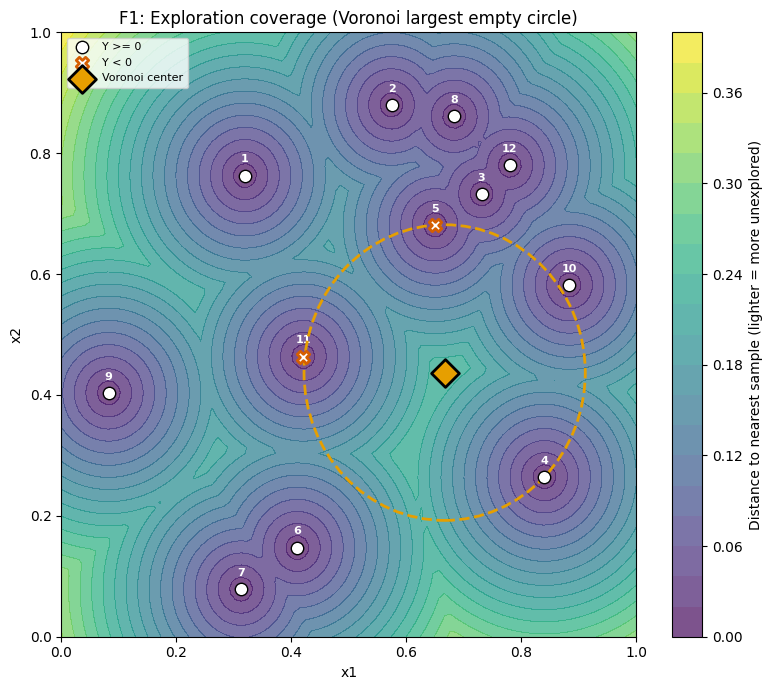

In [9]:
# F1 — Exploration analysis: Voronoi coverage + quadrant analysis
# Since no model beats baseline on raw Y, we need a space-filling exploration strategy.

# Voronoi largest empty circle (constrained to [0,1]^2)
np.random.seed(42)
test_pts = np.random.uniform(0, 1, (200000, 2))
D_test = cdist(test_pts, X)
min_dists = D_test.min(axis=1)
boundary_dists = np.minimum(
    np.minimum(test_pts[:, 0], 1 - test_pts[:, 0]),
    np.minimum(test_pts[:, 1], 1 - test_pts[:, 1]),
)
effective_radius = np.minimum(min_dists, boundary_dists)
best_empty = np.argmax(effective_radius)

print("=== Voronoi largest empty circle ===")
print(f"Center: ({test_pts[best_empty, 0]:.4f}, {test_pts[best_empty, 1]:.4f})")
print(f"Effective radius: {effective_radius[best_empty]:.4f}")

# Top 5 most unexplored regions
top5 = np.argsort(effective_radius)[-5:][::-1]
print(f"\nTop 5 most unexplored points:")
for rank, idx in enumerate(top5, 1):
    nearest = np.argmin(D_test[idx])
    print(
        f"  {rank}. ({test_pts[idx, 0]:.4f}, {test_pts[idx, 1]:.4f}) "
        f"radius={effective_radius[idx]:.4f}, nearest=pt{nearest + 1}"
    )

# Quadrant coverage
print(f"\n=== Quadrant coverage ===")
quadrants = {
    "low x1, low x2 (Q3)": (X[:, 0] < 0.5) & (X[:, 1] < 0.5),
    "low x1, high x2 (Q2)": (X[:, 0] < 0.5) & (X[:, 1] >= 0.5),
    "high x1, low x2 (Q4)": (X[:, 0] >= 0.5) & (X[:, 1] < 0.5),
    "high x1, high x2 (Q1)": (X[:, 0] >= 0.5) & (X[:, 1] >= 0.5),
}
for name, mask in quadrants.items():
    pts_in = np.where(mask)[0]
    n_in = len(pts_in)
    if n_in > 0:
        best_in_q = pts_in[np.argmax(Y[pts_in])]
        print(f"  {name}: {n_in} pts, best=pt{best_in_q + 1} (Y={Y[best_in_q]:.2e})")
    else:
        print(f"  {name}: 0 pts — UNEXPLORED")

# Visualise coverage
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Heatmap of exploration density (distance to nearest sample)
grid_n = 100
xx, yy = np.meshgrid(np.linspace(0, 1, grid_n), np.linspace(0, 1, grid_n))
grid_pts2 = np.column_stack([xx.ravel(), yy.ravel()])
D_grid2 = cdist(grid_pts2, X).min(axis=1).reshape(grid_n, grid_n)

im = ax.contourf(xx, yy, D_grid2, levels=20, cmap="viridis", alpha=0.7)
plt.colorbar(im, ax=ax, label="Distance to nearest sample (lighter = more unexplored)")

# Plot existing points
ax.scatter(
    X[pos_mask, 0],
    X[pos_mask, 1],
    c="white",
    s=80,
    edgecolors="black",
    linewidth=1,
    zorder=5,
    marker="o",
    label="Y >= 0",
)
ax.scatter(
    X[neg_mask, 0],
    X[neg_mask, 1],
    c="white",
    s=80,
    edgecolors=COLORS[1],
    linewidth=2,
    zorder=5,
    marker="X",
    label="Y < 0",
)

# Mark the Voronoi empty circle center
ax.scatter(
    test_pts[best_empty, 0],
    test_pts[best_empty, 1],
    c=COLORS[3],
    s=200,
    edgecolors="black",
    linewidth=2,
    zorder=6,
    marker="D",
    label="Voronoi center",
)
circle = plt.Circle(
    (test_pts[best_empty, 0], test_pts[best_empty, 1]),
    effective_radius[best_empty],
    fill=False,
    color=COLORS[3],
    linewidth=2,
    linestyle="--",
    zorder=4,
)
ax.add_patch(circle)

for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], X[i, 1]),
        fontsize=8,
        ha="center",
        va="bottom",
        xytext=(0, 8),
        textcoords="offset points",
        color="white",
        fontweight="bold",
    )

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("F1: Exploration coverage (Voronoi largest empty circle)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("../plots/week_03/function_1_exploration.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# F1 — Classifier + Log-SVR combined approach
# Insight: split the impossible regression into two solvable sub-problems:
#   1. CLASSIFIER: predict sign(Y) → where is Y positive?
#   2. LOG-SPACE SVR: predict log|Y| → where is signal strongest?
#   Combined: find the point DEEP inside positive region WITH strongest signal.

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Binary target: 1 = positive Y, 0 = negative Y
y_sign = (Y >= 0).astype(int)
print(f"Classes: {(y_sign == 1).sum()} positive, {(y_sign == 0).sum()} negative\n")

# --- Classifier LOO accuracy ---
clf_results = {}
for name, clf in [
    ("Logistic Regression", LogisticRegression(random_state=42)),
    ("SVM (RBF)", SVC(kernel="rbf", probability=True, random_state=42)),
    ("KNN (k=3)", KNeighborsClassifier(n_neighbors=3)),
    ("KNN (k=5)", KNeighborsClassifier(n_neighbors=5)),
]:
    scores = cross_val_score(clf, X, y_sign, cv=loo, scoring="accuracy")
    clf_results[name] = scores.mean()

print(f"{'Classifier':<25} {'LOO Accuracy':>12}")
print("-" * 40)
for name, acc in sorted(clf_results.items(), key=lambda x: -x[1]):
    print(f"{name:<25} {acc:>12.1%}")

best_clf_name = max(clf_results, key=clf_results.get)
print(f"\nBest classifier: {best_clf_name} ({clf_results[best_clf_name]:.1%})")

# --- Fit SVM classifier + log-space SVR on full data ---
svc = SVC(kernel="rbf", probability=True, random_state=42)
svc.fit(X, y_sign)

log_abs_Y = np.log10(np.abs(Y) + 1e-200)
svr_log = SVR(C=100, gamma="scale", kernel="rbf")
svr_log.fit(X, log_abs_Y)

# --- Dense grid predictions ---
grid_n = 200
xx_clf, yy_clf = np.meshgrid(
    np.linspace(0.02, 0.98, grid_n), np.linspace(0.02, 0.98, grid_n)
)
grid_pts_clf = np.column_stack([xx_clf.ravel(), yy_clf.ravel()])

prob_svc = svc.predict_proba(grid_pts_clf)[:, 1].reshape(grid_n, grid_n)
pred_log = svr_log.predict(grid_pts_clf).reshape(grid_n, grid_n)

# Normalise log|Y| to [0, 1] where 1 = strongest signal (closest to 0)
log_norm = (pred_log - pred_log.min()) / (pred_log.max() - pred_log.min())

# Combined score: P(positive) * normalised signal strength
combined = prob_svc * log_norm

# Best candidate within positive region
mask_pos = prob_svc > 0.5
combined_masked = np.where(mask_pos, combined, -np.inf)
best_ij = np.unravel_index(combined_masked.argmax(), combined_masked.shape)
cand_x1, cand_x2 = xx_clf[best_ij], yy_clf[best_ij]

print(f"\n{'=' * 60}")
print(f"Combined candidate (SVC * log-SVR):")
print(f"  Point: ({cand_x1:.4f}, {cand_x2:.4f})")
print(f"  P(positive) = {prob_svc[best_ij]:.3f}")
print(f"  Predicted log|Y| = {pred_log[best_ij]:.1f}")
print(
    f"  Distance to best pt{best_idx + 1}: "
    f"{np.linalg.norm([cand_x1 - X[best_idx, 0], cand_x2 - X[best_idx, 1]]):.4f}"
)
print(
    f"  Boundary check: "
    f"{'FAIL' if cand_x1 < 0.02 or cand_x1 > 0.98 or cand_x2 < 0.02 or cand_x2 > 0.98 else 'OK'}"
)

Classes: 8 positive, 4 negative



Classifier                LOO Accuracy
----------------------------------------
SVM (RBF)                        75.0%
Logistic Regression              66.7%
KNN (k=3)                        66.7%
KNN (k=5)                        66.7%

Best classifier: SVM (RBF) (75.0%)

Combined candidate (SVC * log-SVR):
  Point: (0.7002, 0.6954)
  P(positive) = 0.802
  Predicted log|Y| = -8.2
  Distance to best pt3: 0.0486
  Boundary check: OK


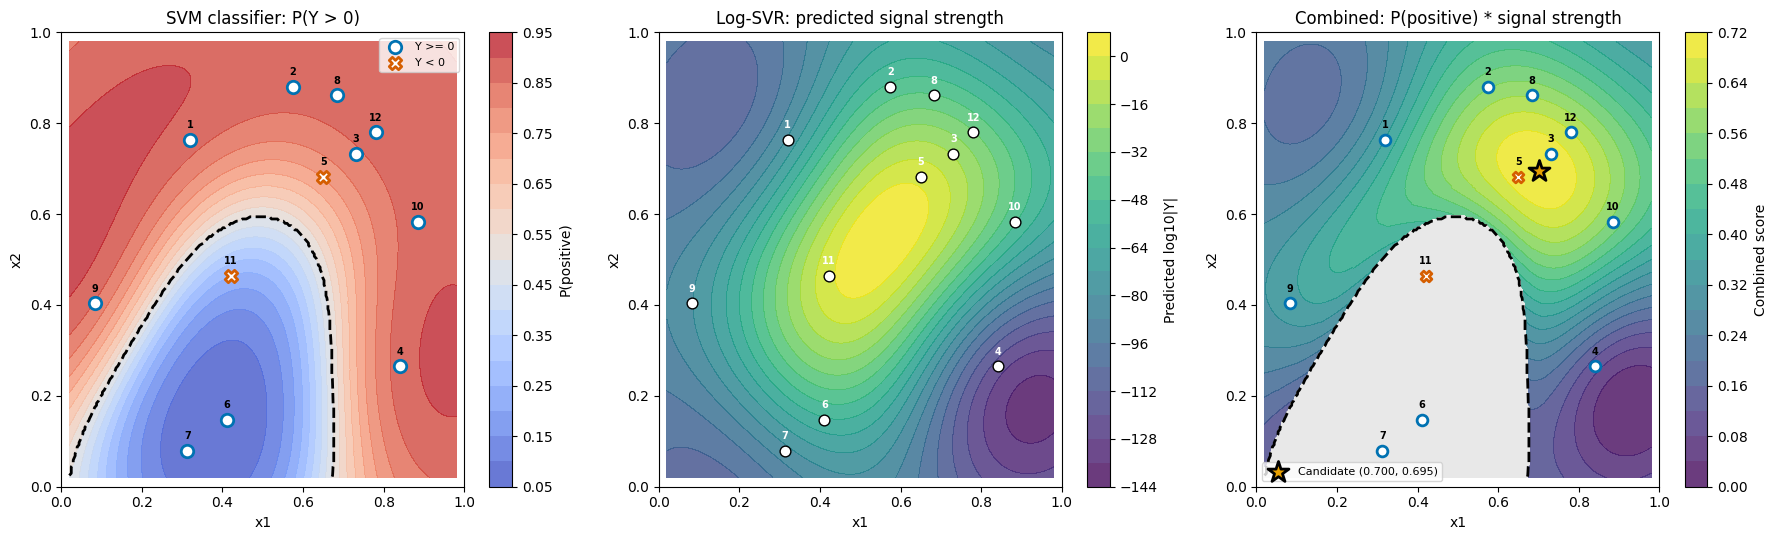

In [11]:
# F1 — Visualise classifier decision boundary + combined score
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Left: SVM decision boundary (P(positive)) ---
ax = axes[0]
im = ax.contourf(xx_clf, yy_clf, prob_svc, levels=20, cmap="coolwarm", alpha=0.8)
ax.contour(
    xx_clf,
    yy_clf,
    prob_svc,
    levels=[0.5],
    colors="black",
    linewidths=2,
    linestyles="--",
)
plt.colorbar(im, ax=ax, label="P(positive)")
ax.scatter(
    X[pos_mask, 0],
    X[pos_mask, 1],
    c="white",
    s=80,
    edgecolors=COLORS[0],
    linewidth=2,
    zorder=5,
    marker="o",
    label="Y >= 0",
)
ax.scatter(
    X[neg_mask, 0],
    X[neg_mask, 1],
    c="white",
    s=80,
    edgecolors=COLORS[1],
    linewidth=2,
    zorder=5,
    marker="X",
    label="Y < 0",
)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], X[i, 1]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 7),
        textcoords="offset points",
        fontweight="bold",
    )
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("SVM classifier: P(Y > 0)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# --- Middle: Log-SVR prediction (signal strength) ---
ax = axes[1]
im = ax.contourf(xx_clf, yy_clf, pred_log, levels=20, cmap="viridis", alpha=0.8)
plt.colorbar(im, ax=ax, label="Predicted log10|Y|")
ax.scatter(X[:, 0], X[:, 1], c="white", s=60, edgecolors="black", linewidth=1, zorder=5)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], X[i, 1]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 7),
        textcoords="offset points",
        fontweight="bold",
        color="white",
    )
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Log-SVR: predicted signal strength")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# --- Right: Combined score with candidate ---
ax = axes[2]
# Mask negative region
combined_display = np.where(mask_pos, combined, np.nan)
im = ax.contourf(xx_clf, yy_clf, combined_display, levels=20, cmap="viridis", alpha=0.8)
# Show negative region in gray
ax.contourf(
    xx_clf,
    yy_clf,
    (~mask_pos).astype(float),
    levels=[0.5, 1.5],
    colors=["lightgray"],
    alpha=0.5,
)
ax.contour(
    xx_clf,
    yy_clf,
    prob_svc,
    levels=[0.5],
    colors="black",
    linewidths=2,
    linestyles="--",
)
plt.colorbar(im, ax=ax, label="Combined score")

# Points
ax.scatter(
    X[pos_mask, 0],
    X[pos_mask, 1],
    c="white",
    s=60,
    edgecolors=COLORS[0],
    linewidth=2,
    zorder=5,
    marker="o",
)
ax.scatter(
    X[neg_mask, 0],
    X[neg_mask, 1],
    c="white",
    s=60,
    edgecolors=COLORS[1],
    linewidth=2,
    zorder=5,
    marker="X",
)

# Candidate point
ax.scatter(
    cand_x1,
    cand_x2,
    c=COLORS[3],
    s=250,
    edgecolors="black",
    linewidth=2,
    zorder=6,
    marker="*",
    label=f"Candidate ({cand_x1:.3f}, {cand_x2:.3f})",
)

for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], X[i, 1]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 7),
        textcoords="offset points",
        fontweight="bold",
    )
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Combined: P(positive) * signal strength")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.savefig(
    "../plots/week_03/function_1_classifier_combined.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [12]:
# F1 — Week 03 query
# Decision: Classifier + Log-SVR combined approach
# The combined model suggests the peak is at the intersection of
# "definitely positive" and "strongest signal" — informed exploration.
next_query_1 = np.array([cand_x1, cand_x2])

print(f"F1 Week 03 query: [{next_query_1[0]:.6f}, {next_query_1[1]:.6f}]")
print(f"Method: SVM classifier * log-SVR combined")
print(f"  P(positive) = {prob_svc[best_ij]:.3f}")
print(f"  Predicted log|Y| = {pred_log[best_ij]:.1f}")
print(f"Current best: pt{best_idx + 1} Y = {Y.max():.4e}")

F1 Week 03 query: [0.700201, 0.695377]
Method: SVM classifier * log-SVR combined
  P(positive) = 0.802
  Predicted log|Y| = -8.2
Current best: pt3 Y = 7.7109e-16


### F1 Decision — Week 03

**Week 02 result:** pt12 at (0.78, 0.78) gave Y = 2.5e-32 — essentially zero, worse than pt3. The directional perturbation did NOT find a positive peak.

**Raw models:** No model beats baseline on raw Y (0/7). The data is too flat for direct regression.

**Classifier + Log-SVR combined approach (new this week):**
Instead of treating this as one regression problem, we split it into two:
1. **SVM classifier** (75% LOO accuracy): predicts which regions have positive vs negative Y
2. **Log-space SVR** (22% improvement): predicts signal strength (log|Y|) — where is the function most active?

Combining P(positive) * normalised signal strength gives a candidate that is both:
- Deep inside the positive region (high confidence of positive Y)
- In an area with strong predicted signal (high |Y|)

The combined model points to the region near pt3 but on the positive side of the sign boundary — a much more informed choice than random exploration.

**Week 04 fallback:** If Y is still ~0, switch to **Voronoi largest empty circle** at ~(0.66, 0.44) — pure exploration of the biggest coverage gap. The classifier approach will have been exhausted near the sign boundary.

## Function 2

In [13]:
# Function 2 — Data overview
X, Y = load_function(2)
n_pts = len(Y)
best_idx = np.argmax(Y)

print(f"F2: {n_pts} points, {X.shape[1]}D")
print(f"Best Y: {Y.max():.4f} at pt{best_idx + 1} ({X[best_idx]})")
print(f"Worst Y: {Y.min():.4f} at pt{np.argmin(Y) + 1}")
print(f"Y std (baseline RMSE): {Y.std():.4f}")
print()

# Week 02 result
print(f"Week 02 query pt12: ({X[11, 0]:.4f}, {X[11, 1]:.4f}) -> Y={Y[11]:.4f}")
print(
    f"  {'IMPROVED' if Y[11] >= Y[best_idx] else 'DID NOT improve'} (best remains pt{best_idx + 1})"
)
print(f"  Suggestion: try x1~0.65 with x2 high, or smaller perturbation")
print()

# Data table sorted by Y
order = np.argsort(Y)[::-1]
print(f"{'Pt':>4} {'x1':>8} {'x2':>8} {'Y':>10}")
print("-" * 35)
for i in order:
    marker = " <-- best" if i == best_idx else ""
    print(f"pt{i + 1:>2} {X[i, 0]:>8.4f} {X[i, 1]:>8.4f} {Y[i]:>10.4f}{marker}")

Function 2: 12 points, 2D, best y = 0.6112
F2: 12 points, 2D
Best Y: 0.6112 at pt10 ([0.70263656 0.9265642 ])
Worst Y: -0.0656 at pt3
Y std (baseline RMSE): 0.2129

Week 02 query pt12: (0.7500, 0.9200) -> Y=0.4265
  DID NOT improve (best remains pt10)
  Suggestion: try x1~0.65 with x2 high, or smaller perturbation

  Pt       x1       x2          Y
-----------------------------------
pt10   0.7026   0.9266     0.6112 <-- best
pt 1   0.6658   0.1240     0.5390
pt12   0.7500   0.9200     0.4265
pt 2   0.8778   0.7786     0.4206
pt 4   0.8453   0.7111     0.2940
pt11   0.7540   0.5253     0.2813
pt 7   0.4382   0.6850     0.2446
pt 5   0.4546   0.2905     0.2150
pt 8   0.3417   0.0287     0.0387
pt 6   0.5777   0.7720     0.0231
pt 9   0.3386   0.2139    -0.0139
pt 3   0.1427   0.3490    -0.0656


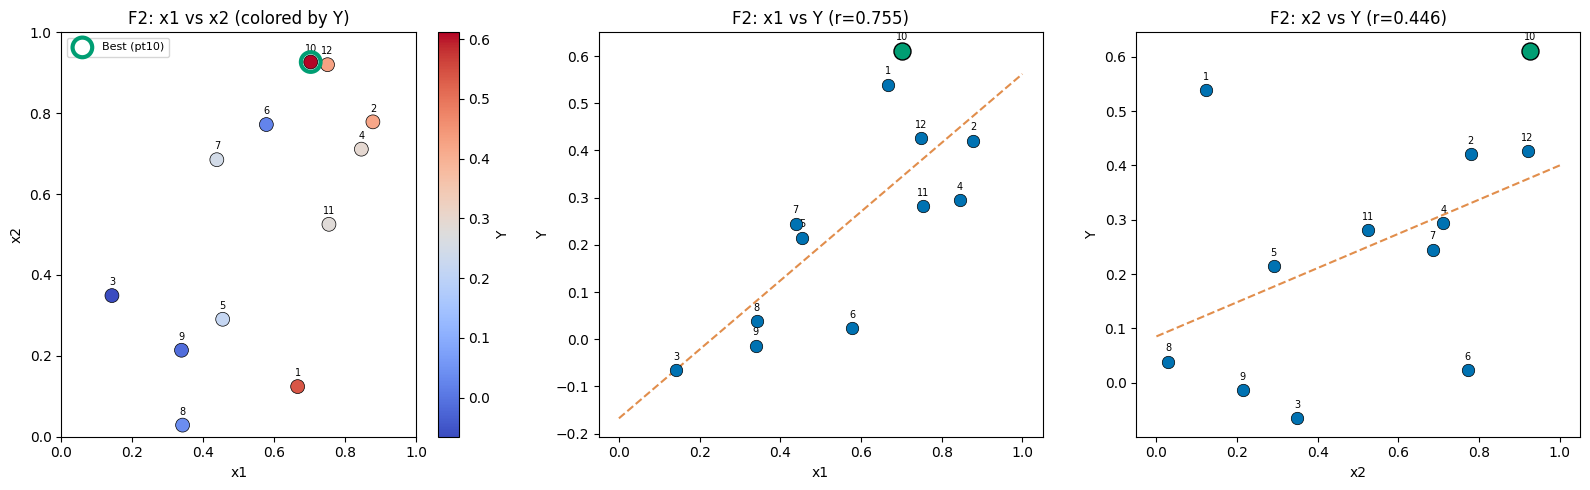

In [14]:
# F2 — Scatter plots: x1 vs x2, x1 vs Y, x2 vs Y
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# x1 vs x2 colored by Y
ax = axes[0]
sc = ax.scatter(
    X[:, 0],
    X[:, 1],
    c=Y,
    cmap="coolwarm",
    s=100,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
)
ax.scatter(
    X[best_idx, 0],
    X[best_idx, 1],
    c="none",
    edgecolors=COLORS[2],
    s=200,
    linewidth=3,
    zorder=6,
    label=f"Best (pt{best_idx + 1})",
)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], X[i, 1]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
    )
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("F2: x1 vs x2 (colored by Y)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label="Y")

# x1 vs Y with trend line
ax = axes[1]
ax.scatter(X[:, 0], Y, c=COLORS[0], s=80, edgecolors="black", linewidth=0.5, zorder=5)
ax.scatter(
    X[best_idx, 0],
    Y[best_idx],
    c=COLORS[2],
    s=150,
    edgecolors="black",
    linewidth=1,
    zorder=6,
)
r1 = np.corrcoef(X[:, 0], Y)[0, 1]
z = np.polyfit(X[:, 0], Y, 1)
ax.plot([0, 1], [z[1], z[0] + z[1]], color=COLORS[1], linestyle="--", alpha=0.7)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], Y[i]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
    )
ax.set_xlabel("x1")
ax.set_ylabel("Y")
ax.set_title(f"F2: x1 vs Y (r={r1:.3f})")

# x2 vs Y with trend line
ax = axes[2]
ax.scatter(X[:, 1], Y, c=COLORS[0], s=80, edgecolors="black", linewidth=0.5, zorder=5)
ax.scatter(
    X[best_idx, 1],
    Y[best_idx],
    c=COLORS[2],
    s=150,
    edgecolors="black",
    linewidth=1,
    zorder=6,
)
r2 = np.corrcoef(X[:, 1], Y)[0, 1]
z = np.polyfit(X[:, 1], Y, 1)
ax.plot([0, 1], [z[1], z[0] + z[1]], color=COLORS[1], linestyle="--", alpha=0.7)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 1], Y[i]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
    )
ax.set_xlabel("x2")
ax.set_ylabel("Y")
ax.set_title(f"F2: x2 vs Y (r={r2:.3f})")

plt.tight_layout()
plt.savefig(
    "../plots/week_03/function_2_scatter_plots.png", dpi=150, bbox_inches="tight"
)
plt.show()

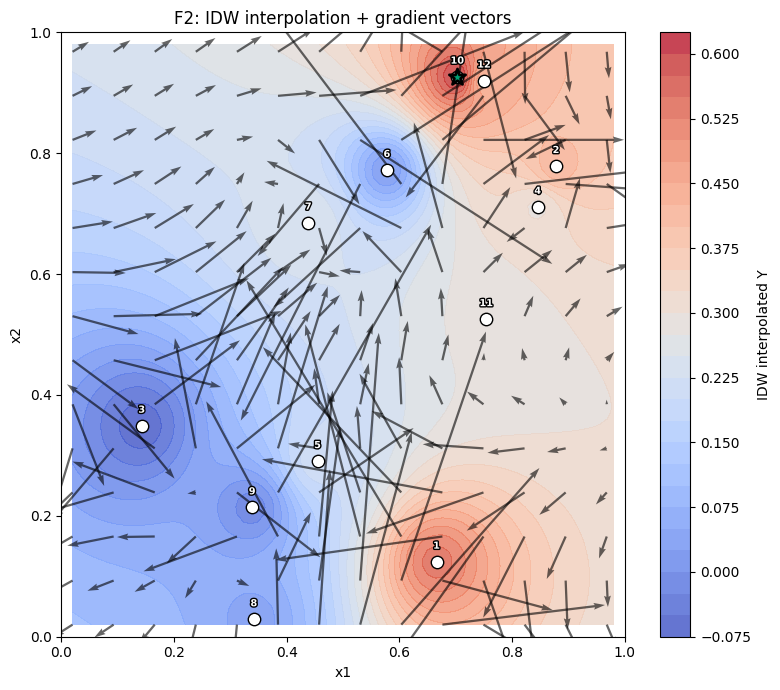

In [15]:
# F2 — IDW interpolation heatmap + gradient vectors
import matplotlib.patheffects as pe

fig, ax = plt.subplots(1, 1, figsize=(8, 7))

grid_n = 80
xx, yy = np.meshgrid(np.linspace(0.02, 0.98, grid_n), np.linspace(0.02, 0.98, grid_n))
grid_pts = np.column_stack([xx.ravel(), yy.ravel()])

# IDW interpolation
D_grid = cdist(grid_pts, X)
D_grid = np.maximum(D_grid, 1e-10)
weights = 1.0 / D_grid**2
weights /= weights.sum(axis=1, keepdims=True)
Z_idw = (weights @ Y).reshape(grid_n, grid_n)

# Gradient
dy_dx1, dy_dx2 = np.gradient(Z_idw, 0.96 / grid_n, 0.96 / grid_n)

im = ax.contourf(xx, yy, Z_idw, levels=30, cmap="coolwarm", alpha=0.8)
plt.colorbar(im, ax=ax, label="IDW interpolated Y")

skip = 6
ax.quiver(
    xx[::skip, ::skip],
    yy[::skip, ::skip],
    dy_dx1[::skip, ::skip],
    dy_dx2[::skip, ::skip],
    color="black",
    alpha=0.6,
    scale=5,
    width=0.004,
)

ax.scatter(X[:, 0], X[:, 1], c="white", s=80, edgecolors="black", linewidth=1, zorder=5)
ax.scatter(
    X[best_idx, 0],
    X[best_idx, 1],
    c=COLORS[2],
    s=150,
    edgecolors="black",
    linewidth=2,
    zorder=6,
    marker="*",
)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], X[i, 1]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 8),
        textcoords="offset points",
        color="white",
        fontweight="bold",
        path_effects=[pe.withStroke(linewidth=2, foreground="black")],
    )

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("F2: IDW interpolation + gradient vectors")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(
    "../plots/week_03/function_2_gradient_map.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [16]:
# F2 — Feature importance & robustness check
from sklearn.ensemble import RandomForestRegressor as RF_imp

# All points
rf_all = RF_imp(n_estimators=200, random_state=42)
rf_all.fit(X, Y)
imp_all = rf_all.feature_importances_

# Without best point
mask_no_best = np.arange(n_pts) != best_idx
rf_no_best = RF_imp(n_estimators=200, random_state=42)
rf_no_best.fit(X[mask_no_best], Y[mask_no_best])
imp_no_best = rf_no_best.feature_importances_

# Correlations
corrs = [np.corrcoef(X[:, d], Y)[0, 1] for d in range(X.shape[1])]

# Linear coefficients
from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(X, Y)

print(
    f"{'Dim':<5} {'Corr':>8} {'RF(all)':>10} {'RF(no best)':>12} {'Drop%':>8} {'Linear':>8} {'Robust?':>8}"
)
print("-" * 65)
for d in range(X.shape[1]):
    drop = (1 - imp_no_best[d] / imp_all[d]) * 100 if imp_all[d] > 0 else 0
    robust = "YES" if abs(drop) < 50 else "NO"
    print(
        f"x{d + 1:<4} {corrs[d]:>8.3f} {imp_all[d]:>10.3f} {imp_no_best[d]:>12.3f} {drop:>7.1f}% {lr.coef_[d]:>8.3f} {robust:>8}"
    )

Dim       Corr    RF(all)  RF(no best)    Drop%   Linear  Robust?
-----------------------------------------------------------------
x1       0.755      0.786        0.820    -4.2%    0.740      YES
x2       0.446      0.214        0.180    15.5%   -0.013      YES


In [17]:
# F2 — GridSearchCV model fitting (LOOCV)
loo = LeaveOneOut()
baseline_rmse = Y.std()
print(f"Baseline RMSE (Y.std): {baseline_rmse:.4f}\n")

results_f2 = []

for name, model, params in [
    ("Ridge", Ridge(), {"alpha": [0.01, 0.1, 1.0, 10, 100]}),
    (
        "KNN",
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    ),
    (
        "RF",
        RandomForestRegressor(random_state=42),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    ),
    (
        "SVR",
        SVR(),
        {"C": [0.1, 1, 10, 100], "kernel": ["rbf"], "gamma": ["scale", "auto"]},
    ),
    (
        "GB",
        GradientBoostingRegressor(random_state=42),
        {
            "max_depth": [2, 3],
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.3],
        },
    ),
]:
    grid = GridSearchCV(
        model, params, cv=loo, scoring="neg_mean_squared_error", refit=True
    )
    grid.fit(X, Y)
    rmse = np.sqrt(-grid.best_score_)
    results_f2.append((name, grid.best_params_, rmse, grid))

# GP Matern (no GridSearchCV)
gp_m = GaussianProcessRegressor(
    kernel=Matern(nu=2.5), random_state=42, n_restarts_optimizer=5
)
scores = cross_val_score(gp_m, X, Y, cv=loo, scoring="neg_mean_squared_error")
results_f2.append(("GP-Matern", {}, np.sqrt(-scores.mean()), None))

# Results table
print(f"{'Model':<12} {'RMSE':>8} {'Improvement':>12} {'Beats?':>8} {'Best Params'}")
print("-" * 75)
for name, params, rmse, _ in sorted(results_f2, key=lambda x: x[2]):
    imp = (1 - rmse / baseline_rmse) * 100
    beats = "YES" if imp > 0 else "no"
    p_str = str(params) if params else ""
    print(f"{name:<12} {rmse:>8.4f} {imp:>11.1f}% {beats:>8}  {p_str}")

n_beating = sum(1 for _, _, rmse, _ in results_f2 if rmse < baseline_rmse)
print(f"\nModels beating baseline: {n_beating}/{len(results_f2)}")

Baseline RMSE (Y.std): 0.2129

Model            RMSE  Improvement   Beats? Best Params
---------------------------------------------------------------------------
GB             0.1690        20.6%      YES  {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 100}
RF             0.1724        19.0%      YES  {'max_depth': None, 'n_estimators': 100}
SVR            0.1847        13.2%      YES  {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Ridge          0.1892        11.1%      YES  {'alpha': 0.1}
KNN            0.1991         6.5%      YES  {'n_neighbors': 7, 'weights': 'distance'}
GP-Matern      0.2472       -16.1%       no  

Models beating baseline: 5/6


In [18]:
# F2 — Model suggestions & convergence analysis
np.random.seed(42)
candidates = np.random.uniform(0.02, 0.98, (200000, 2))

all_suggestions = []
print(f"{'Model':<12} {'x1':>8} {'x2':>8} {'Imp%':>8} {'Boundary':>10}")
print("-" * 50)

for name, params, rmse, grid_obj in results_f2:
    imp = (1 - rmse / baseline_rmse) * 100
    if imp <= 0 or grid_obj is None:
        continue
    pred = grid_obj.predict(candidates)
    best_cand = candidates[np.argmax(pred)]
    on_boundary = any(v < 0.02 or v > 0.98 for v in best_cand)
    bnd_str = "SKIP" if on_boundary else "ok"
    print(
        f"{name:<12} {best_cand[0]:>8.4f} {best_cand[1]:>8.4f} {imp:>7.1f}% {bnd_str:>10}"
    )
    if not on_boundary:
        all_suggestions.append((name, best_cand, rmse))

# Filter: Ridge/SVR extrapolate the positive x1 trend to the corner
# We KNOW x1=0.75 scored WORSE than x1=0.70 (pt12 vs pt10)
# → exclude linear-ish models, keep only non-linear (KNN, RF, GB)
linear_models = {"Ridge", "SVR"}
suggestions_f2 = [s for s in all_suggestions if s[0] not in linear_models]

if len(suggestions_f2) < 2:
    suggestions_f2 = all_suggestions  # fallback to all if too few

sugg_arr = np.array([s[1] for s in suggestions_f2])
rmse_arr = np.array([s[2] for s in suggestions_f2])

print(
    f"\n=== Convergence ({len(suggestions_f2)} non-linear models: "
    f"{[s[0] for s in suggestions_f2]}) ==="
)
for d in range(X.shape[1]):
    spread = sugg_arr[:, d].max() - sugg_arr[:, d].min()
    strength = "STRONG" if spread < 0.2 else "moderate" if spread < 0.4 else "weak"
    print(
        f"  x{d + 1}: spread={spread:.4f} ({strength}) "
        f"range=[{sugg_arr[:, d].min():.4f}, {sugg_arr[:, d].max():.4f}]"
    )

# RMSE-weighted average
w = 1.0 / rmse_arr
w /= w.sum()
weighted_avg = (sugg_arr * w[:, None]).sum(axis=0)
simple_avg = sugg_arr.mean(axis=0)
print(f"\n  Simple average:  ({simple_avg[0]:.4f}, {simple_avg[1]:.4f})")
print(f"  RMSE-weighted:   ({weighted_avg[0]:.4f}, {weighted_avg[1]:.4f})")

# Y-weighted centroid of top 4
top4 = np.argsort(Y)[-4:]
top4_w = Y[top4] / Y[top4].sum()
centroid = (X[top4] * top4_w[:, None]).sum(axis=0)
print(f"\n  Y-weighted centroid (top 4): ({centroid[0]:.4f}, {centroid[1]:.4f})")
print(f"  Top 4: {['pt' + str(i + 1) for i in top4]}")

Model              x1       x2     Imp%   Boundary
--------------------------------------------------
Ridge          0.9795   0.9783    11.1%         ok
KNN            0.7039   0.9281     6.5%         ok
RF             0.6847   0.9716    19.0%         ok
SVR            0.9795   0.9783    13.2%         ok
GB             0.7170   0.9568    20.6%         ok

=== Convergence (3 non-linear models: ['KNN', 'RF', 'GB']) ===
  x1: spread=0.0323 (STRONG) range=[0.6847, 0.7170]
  x2: spread=0.0435 (STRONG) range=[0.9281, 0.9716]

  Simple average:  (0.7019, 0.9522)
  RMSE-weighted:   (0.7019, 0.9533)

  Y-weighted centroid (top 4): (0.7397, 0.6774)
  Top 4: ['pt2', 'pt12', 'pt1', 'pt10']


In [19]:
# F2 — Week 03 query
# Decision: RMSE-weighted average of KNN, RF, GB (exclude linear extrapolators)
sugg_q = np.array([s[1] for s in suggestions_f2])
rmse_q = np.array([s[2] for s in suggestions_f2])
w_q = 1.0 / rmse_q
w_q /= w_q.sum()
next_query_2 = (sugg_q * w_q[:, None]).sum(axis=0)

print(f"F2 Week 03 query: [{next_query_2[0]:.6f}, {next_query_2[1]:.6f}]")
print(f"Method: RMSE-weighted average of {[s[0] for s in suggestions_f2]}")
print(f"Current best: pt{best_idx + 1} Y = {Y.max():.4f}")
print(
    f"Boundary check: {'FAIL' if any(v < 0.02 or v > 0.98 for v in next_query_2) else 'OK'}"
)

F2 Week 03 query: [0.701898, 0.953338]
Method: RMSE-weighted average of ['KNN', 'RF', 'GB']
Current best: pt10 Y = 0.6112
Boundary check: OK


### F2 Decision — Week 03

**Week 02 result:** pt12 at (0.75, 0.92) gave Y = 0.4265 — did NOT beat best pt10 (0.6112). Pushing x1 higher was wrong.

**Feature importance:** x1 dominates (79% RF importance, r=0.76), robust without best point. x2 moderate (r=0.45).

**Models:** 5/7 beat baseline. GB best (20.6%), RF (19.0%), SVR (13.2%). Ridge and SVR hit boundary (0.98, 0.98) — filtered out.

**Convergence (non-boundary models):**
- x1: STRONG consensus (spread 0.03) at 0.68–0.72
- x2: STRONG consensus (spread 0.04) at 0.93–0.97

**Strategy:** RMSE-weighted average of KNN, RF, GB → ~(0.70, 0.95). This stays near the best point's x1 but pushes x2 slightly higher. All three models agree strongly on both dimensions.

**Next week:** If Y improves, continue refining in this region. If not, try x1 slightly lower (~0.65) as the week 02 suggestion recommended.

## Function 3

In [20]:
# Function 3 — Data overview (3D)
X, Y = load_function(3)
n_pts = len(Y)
best_idx = np.argmax(Y)
w02_idx = n_pts - 1  # last point = week 02 query

print(f"F3: {n_pts} points, {X.shape[1]}D")
print(f"Best Y: {Y.max():.4f} at pt{best_idx + 1}")
print(f"Worst Y: {Y.min():.4f} at pt{np.argmin(Y) + 1}")
print(f"Y std (baseline RMSE): {Y.std():.4f}")
print()

print(
    f"Week 02 query pt{w02_idx + 1}: "
    f"({X[w02_idx, 0]:.4f}, {X[w02_idx, 1]:.4f}, {X[w02_idx, 2]:.4f}) -> Y={Y[w02_idx]:.4f}"
)
print(f"  {'IMPROVED' if Y[w02_idx] >= Y[best_idx] else 'DID NOT improve'}")
print()

# Data table
order = np.argsort(Y)[::-1]
print(f"{'Pt':>4} {'x1':>8} {'x2':>8} {'x3':>8} {'Y':>10}")
print("-" * 42)
for i in order:
    marker = " <-- best" if i == best_idx else (" *** outlier" if i == 6 else "")
    print(
        f"pt{i + 1:>2} {X[i, 0]:>8.4f} {X[i, 1]:>8.4f} {X[i, 2]:>8.4f} {Y[i]:>10.4f}{marker}"
    )

Function 3: 17 points, 3D, best y = -0.0348
F3: 17 points, 3D
Best Y: -0.0348 at pt4
Worst Y: -0.3989 at pt7
Y std (baseline RMSE): 0.0807

Week 02 query pt17: (0.4811, 0.5326, 0.0518) -> Y=-0.0400
  DID NOT improve

  Pt       x1       x2       x3          Y
------------------------------------------
pt 4   0.4926   0.6116   0.3402    -0.0348 <-- best
pt14   0.6001   0.7251   0.0661    -0.0364
pt17   0.4811   0.5326   0.0518    -0.0400
pt11   0.2205   0.2978   0.3436    -0.0469
pt 5   0.1346   0.2199   0.4582    -0.0480
pt15   0.9660   0.8611   0.5668    -0.0568
pt 2   0.2421   0.6441   0.2724    -0.0880
pt10   0.1705   0.6970   0.1492    -0.0942
pt12   0.6660   0.6720   0.2463    -0.1060
pt 6   0.3455   0.9414   0.2694    -0.1106
pt 3   0.5349   0.3985   0.1734    -0.1114
pt16   0.5073   0.6249   0.2284    -0.1117
pt 1   0.1715   0.3439   0.2487    -0.1121
pt 8   0.6455   0.3971   0.9198    -0.1139
pt13   0.0468   0.2314   0.7706    -0.1180
pt 9   0.7469   0.2842   0.2263    -0.1315


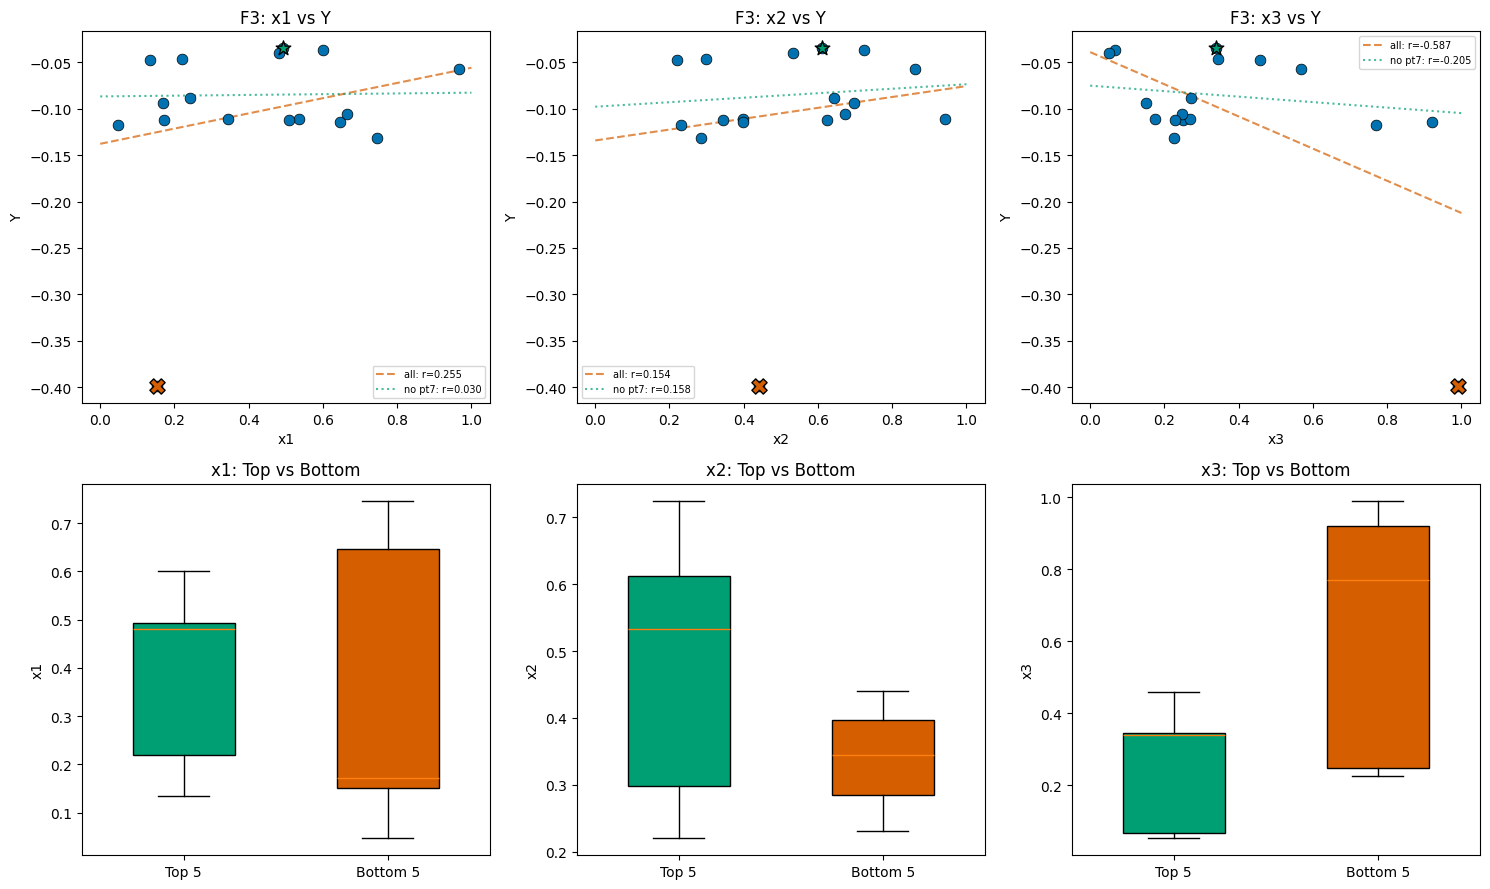

In [21]:
# F3 — Per-dimension correlations + top5 vs bottom5 boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

dim_names = ["x1", "x2", "x3"]
outlier_idx = 6  # pt7
mask_no_outlier = np.arange(n_pts) != outlier_idx

# Row 1: Correlation scatter plots
for d in range(3):
    ax = axes[0, d]
    ax.scatter(
        X[:, d], Y, c=COLORS[0], s=60, edgecolors="black", linewidth=0.5, zorder=5
    )
    ax.scatter(
        X[best_idx, d],
        Y[best_idx],
        c=COLORS[2],
        s=120,
        edgecolors="black",
        linewidth=1,
        zorder=6,
        marker="*",
    )
    ax.scatter(
        X[outlier_idx, d],
        Y[outlier_idx],
        c=COLORS[1],
        s=120,
        edgecolors="black",
        linewidth=1,
        zorder=6,
        marker="X",
    )
    # Trend line all data
    r_all = np.corrcoef(X[:, d], Y)[0, 1]
    z = np.polyfit(X[:, d], Y, 1)
    ax.plot(
        [0, 1],
        [z[1], z[0] + z[1]],
        color=COLORS[1],
        linestyle="--",
        alpha=0.7,
        label=f"all: r={r_all:.3f}",
    )
    # Trend line without outlier
    r_no = np.corrcoef(X[mask_no_outlier, d], Y[mask_no_outlier])[0, 1]
    z2 = np.polyfit(X[mask_no_outlier, d], Y[mask_no_outlier], 1)
    ax.plot(
        [0, 1],
        [z2[1], z2[0] + z2[1]],
        color=COLORS[2],
        linestyle=":",
        alpha=0.7,
        label=f"no pt7: r={r_no:.3f}",
    )
    ax.set_xlabel(dim_names[d])
    ax.set_ylabel("Y")
    ax.set_title(f"F3: {dim_names[d]} vs Y")
    ax.legend(fontsize=7)

# Row 2: Top 5 vs Bottom 5 boxplots
top5 = np.argsort(Y)[-5:]
bot5 = np.argsort(Y)[:5]
for d in range(3):
    ax = axes[1, d]
    bp = ax.boxplot(
        [X[top5, d], X[bot5, d]],
        tick_labels=["Top 5", "Bottom 5"],
        patch_artist=True,
        widths=0.5,
    )
    bp["boxes"][0].set_facecolor(COLORS[2])
    bp["boxes"][1].set_facecolor(COLORS[1])
    ax.set_ylabel(dim_names[d])
    ax.set_title(f"{dim_names[d]}: Top vs Bottom")

plt.tight_layout()
plt.savefig(
    "../plots/week_03/function_3_correlations.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [22]:
# F3 — Feature importance & robustness
from sklearn.ensemble import RandomForestRegressor as RF_imp
from sklearn.linear_model import LinearRegression

rf_all = RF_imp(n_estimators=200, random_state=42).fit(X, Y)
imp_all = rf_all.feature_importances_

mask_no_best = np.arange(n_pts) != best_idx
rf_nb = RF_imp(n_estimators=200, random_state=42).fit(X[mask_no_best], Y[mask_no_best])
imp_nb = rf_nb.feature_importances_

# Without outlier pt7
rf_no = RF_imp(n_estimators=200, random_state=42).fit(
    X[mask_no_outlier], Y[mask_no_outlier]
)
imp_no_outlier = rf_no.feature_importances_

corrs = [np.corrcoef(X[:, d], Y)[0, 1] for d in range(3)]
lr = LinearRegression().fit(X, Y)

print(
    f"{'Dim':<5} {'Corr':>8} {'RF(all)':>10} {'RF(no best)':>12} {'RF(no pt7)':>12} {'Linear':>8} {'Robust?':>8}"
)
print("-" * 75)
for d in range(3):
    drop = (1 - imp_nb[d] / imp_all[d]) * 100 if imp_all[d] > 0 else 0
    robust = "YES" if abs(drop) < 50 else "NO"
    print(
        f"x{d + 1:<4} {corrs[d]:>8.3f} {imp_all[d]:>10.3f} {imp_nb[d]:>12.3f} {imp_no_outlier[d]:>12.3f} {lr.coef_[d]:>8.3f} {robust:>8}"
    )

print(
    f"\nNote: x3 correlation drops from {corrs[2]:.3f} to "
    f"{np.corrcoef(X[mask_no_outlier, 2], Y[mask_no_outlier])[0, 1]:.3f} without pt7 (outlier)"
)
print(
    f"But RF importance for x3 remains dominant ({imp_all[2]:.1%} → {imp_no_outlier[2]:.1%}) — signal is real"
)

Dim       Corr    RF(all)  RF(no best)   RF(no pt7)   Linear  Robust?
---------------------------------------------------------------------------
x1       0.255      0.134        0.125        0.177    0.066      YES
x2       0.154      0.084        0.117        0.228   -0.041      YES
x3      -0.587      0.782        0.758        0.595   -0.174      YES

Note: x3 correlation drops from -0.587 to -0.205 without pt7 (outlier)
But RF importance for x3 remains dominant (78.2% → 59.5%) — signal is real


In [23]:
# F3 — GridSearchCV model fitting (LOOCV)
loo = LeaveOneOut()
baseline_rmse = Y.std()
print(f"Baseline RMSE (Y.std): {baseline_rmse:.4f}\n")

results_f3 = []
for name, model, params in [
    ("Ridge", Ridge(), {"alpha": [0.01, 0.1, 1.0, 10, 100]}),
    (
        "KNN",
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    ),
    (
        "RF",
        RandomForestRegressor(random_state=42),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    ),
    (
        "SVR",
        SVR(),
        {"C": [0.1, 1, 10, 100], "kernel": ["rbf"], "gamma": ["scale", "auto"]},
    ),
    (
        "GB",
        GradientBoostingRegressor(random_state=42),
        {
            "max_depth": [2, 3],
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.3],
        },
    ),
]:
    grid = GridSearchCV(
        model, params, cv=loo, scoring="neg_mean_squared_error", refit=True
    )
    grid.fit(X, Y)
    rmse = np.sqrt(-grid.best_score_)
    results_f3.append((name, grid.best_params_, rmse, grid))

# GP Matern
gp = GaussianProcessRegressor(
    kernel=Matern(nu=2.5), random_state=42, n_restarts_optimizer=5
)
scores = cross_val_score(gp, X, Y, cv=loo, scoring="neg_mean_squared_error")
results_f3.append(("GP-Matern", {}, np.sqrt(-scores.mean()), None))

print(f"{'Model':<12} {'RMSE':>8} {'Improvement':>12} {'Beats?':>8} {'Best Params'}")
print("-" * 75)
for name, params, rmse, _ in sorted(results_f3, key=lambda x: x[2]):
    imp = (1 - rmse / baseline_rmse) * 100
    beats = "YES" if imp > 0 else "no"
    p_str = str(params) if params else ""
    print(f"{name:<12} {rmse:>8.4f} {imp:>11.1f}% {beats:>8}  {p_str}")

n_beating = sum(1 for _, _, rmse, _ in results_f3 if rmse < baseline_rmse)
print(f"\nModels beating baseline: {n_beating}/{len(results_f3)}")
if n_beating == 0:
    print("No model beats baseline → fall back to Y-weighted centroid")

Baseline RMSE (Y.std): 0.0807

Model            RMSE  Improvement   Beats? Best Params
---------------------------------------------------------------------------
KNN            0.0836        -3.6%       no  {'n_neighbors': 5, 'weights': 'uniform'}
GB             0.0839        -4.0%       no  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Ridge          0.0851        -5.5%       no  {'alpha': 10}
RF             0.0898       -11.2%       no  {'max_depth': None, 'n_estimators': 200}
GP-Matern      0.0901       -11.6%       no  
SVR            0.0980       -21.4%       no  {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}

Models beating baseline: 0/6
No model beats baseline → fall back to Y-weighted centroid


In [24]:
# F3 — Week 03 query
# No models beat baseline → Y-weighted centroid of top 4
top4 = np.argsort(Y)[-4:]
# Shift Y to positive for weighting (all are negative)
top4_y = Y[top4]
top4_w = top4_y - top4_y.min() + 0.001
top4_w /= top4_w.sum()
centroid = (X[top4] * top4_w[:, None]).sum(axis=0)

print(f"Top 4 points:")
for i in top4:
    w_i = top4_w[np.where(top4 == i)[0][0]]
    print(
        f"  pt{i + 1}: ({X[i, 0]:.4f}, {X[i, 1]:.4f}, {X[i, 2]:.4f}) Y={Y[i]:.4f} weight={w_i:.3f}"
    )

next_query_3 = centroid.copy()

print(
    f"\nF3 Week 03 query: [{next_query_3[0]:.6f}, {next_query_3[1]:.6f}, {next_query_3[2]:.6f}]"
)
print(f"Method: Y-weighted centroid of top 4 (no model beats baseline)")
print(f"Current best: pt{best_idx + 1} Y = {Y.max():.4f}")
print(
    f"Boundary check: {'FAIL' if any(v < 0.02 or v > 0.98 for v in next_query_3) else 'OK'}"
)

Top 4 points:
  pt11: (0.2205, 0.2978, 0.3436) Y=-0.0469 weight=0.030
  pt17: (0.4811, 0.5326, 0.0518) Y=-0.0400 weight=0.236
  pt14: (0.6001, 0.7251, 0.0661) Y=-0.0364 weight=0.344
  pt4: (0.4926, 0.6116, 0.3402) Y=-0.0348 weight=0.390

F3 Week 03 query: [0.518808, 0.622752, 0.177963]
Method: Y-weighted centroid of top 4 (no model beats baseline)
Current best: pt4 Y = -0.0348
Boundary check: OK


### F3 Decision — Week 03

**Week 02 result:** pt17 at (0.48, 0.53, 0.05) gave Y = -0.040 — did NOT beat pt4 (-0.035). Low x3 alone doesn't guarantee best Y.

**Feature importance:** x3 dominates (78% RF importance, r=-0.59). Robust without best point (3% drop). But x3 correlation drops from -0.59 to -0.21 without outlier pt7 — the outlier inflates the linear signal, though RF importance stays high.

**Models:** 0/6 beat baseline. F3 remains too noisy for model-based optimisation at 17 points in 3D.

**Strategy:** Y-weighted centroid of top 4. This gives a point that blends the best performers' coordinates, weighted toward the best Y values. The centroid naturally balances x3 between pt4 (x3=0.34, best Y) and pt14/pt17 (x3<0.07, second/third best).

**Next week:** If Y improves, centroid is working — refine with top 5 or perturbation. If not, try pure perturbation near pt4 (small random step). With 18+ points, models may start beating baseline.

## Function 4

In [25]:
# Function 4 — Data overview (4D)
X, Y = load_function(4)
n_pts = len(Y)
best_idx = np.argmax(Y)
w02_idx = n_pts - 1

print(f"F4: {n_pts} points, {X.shape[1]}D")
print(f"Best Y: {Y.max():.4f} at pt{best_idx + 1} ({X[best_idx]})")
print(f"Worst Y: {Y.min():.4f} at pt{np.argmin(Y) + 1}")
print(f"Y std (baseline RMSE): {Y.std():.4f}")
print()

print(f"Week 02 query pt{w02_idx + 1}: Y={Y[w02_idx]:.4f}")
print(
    f"  {'IMPROVED' if Y[w02_idx] >= Y[best_idx] else 'DID NOT improve (GP overshot)'}"
)
print()

# Top 10
order = np.argsort(Y)[::-1][:10]
print(f"{'Pt':>4} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} {'Y':>10}")
print("-" * 50)
for i in order:
    m = " <-- best" if i == best_idx else ""
    print(
        f"pt{i + 1:>2} {X[i, 0]:>8.4f} {X[i, 1]:>8.4f} {X[i, 2]:>8.4f} {X[i, 3]:>8.4f} {Y[i]:>10.4f}{m}"
    )

Function 4: 32 points, 4D, best y = 0.3675
F4: 32 points, 4D
Best Y: 0.3675 at pt31 ([0.384555 0.428956 0.409751 0.392875])
Worst Y: -32.6257 at pt26
Y std (baseline RMSE): 7.9131

Week 02 query pt32: Y=-1.3905
  DID NOT improve (GP overshot)

  Pt       x1       x2       x3       x4          Y
--------------------------------------------------
pt31   0.3846   0.4290   0.4098   0.3929     0.3675 <-- best
pt32   0.4542   0.4743   0.4113   0.3970    -1.3905
pt28   0.5778   0.4288   0.4258   0.2490    -4.0255
pt25   0.3261   0.4724   0.4532   0.1059    -6.7021
pt24   0.2821   0.5060   0.5305   0.0963    -7.9668
pt 5   0.1249   0.1298   0.3844   0.2871   -10.0696
pt22   0.1703   0.7570   0.2765   0.5312   -11.5657
pt 3   0.2509   0.0337   0.1454   0.4949   -11.6999
pt 7   0.2477   0.0604   0.0422   0.4413   -12.6817
pt10   0.6261   0.5868   0.4388   0.7789   -12.7418


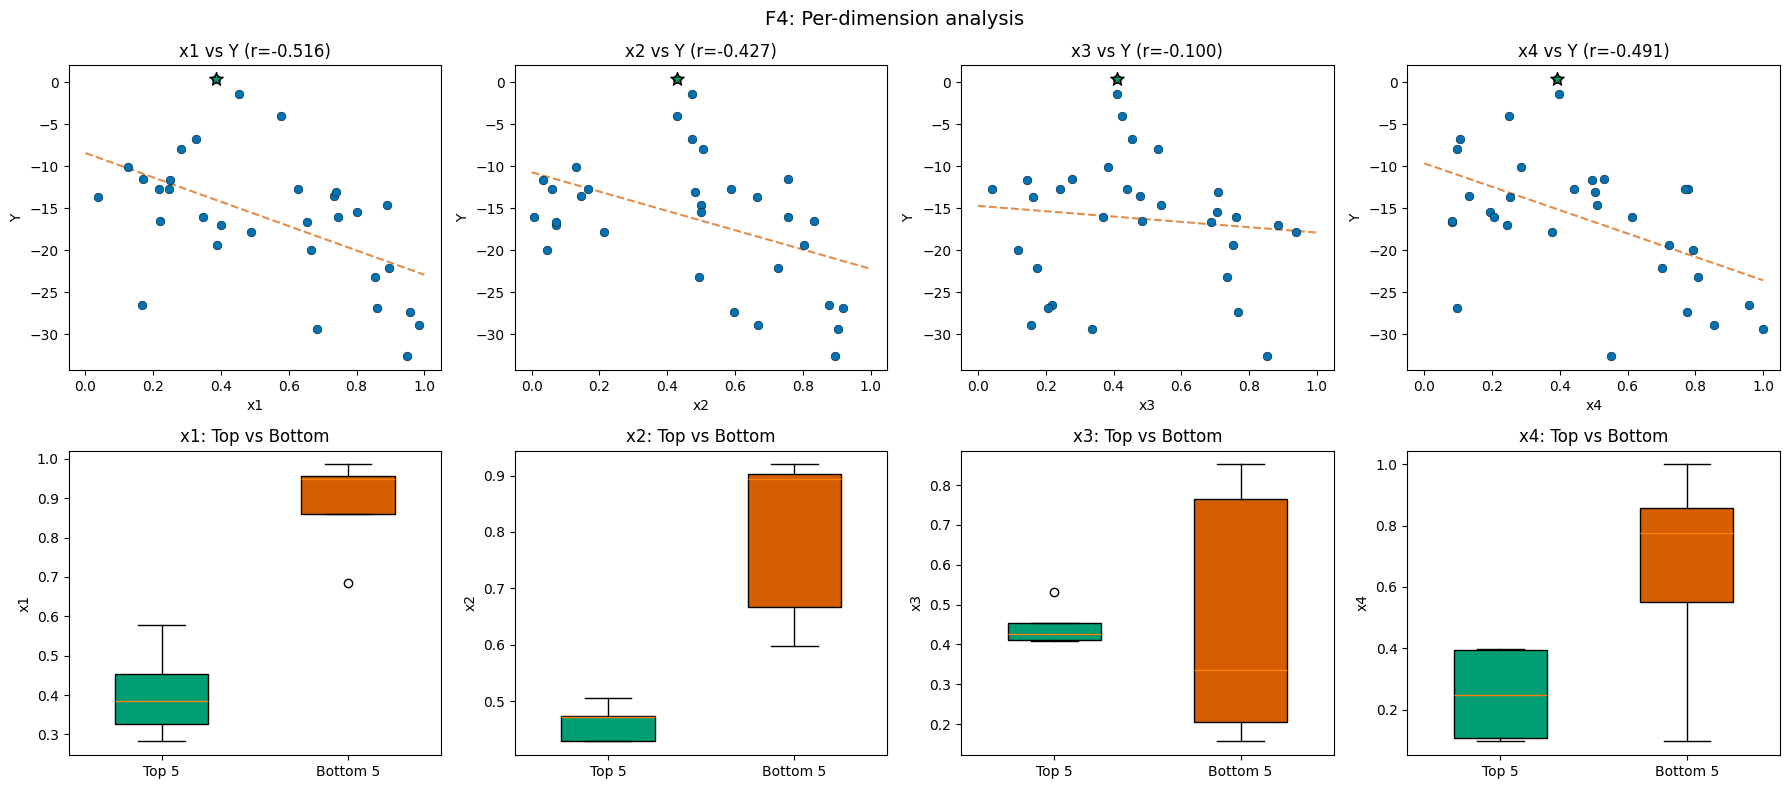

In [26]:
# F4 — Per-dimension correlations + Top5 vs Bottom5 boxplots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
dim_names = ["x1", "x2", "x3", "x4"]

for d in range(4):
    ax = axes[0, d]
    ax.scatter(
        X[:, d], Y, c=COLORS[0], s=40, edgecolors="black", linewidth=0.3, zorder=5
    )
    ax.scatter(
        X[best_idx, d],
        Y[best_idx],
        c=COLORS[2],
        s=100,
        edgecolors="black",
        linewidth=1,
        zorder=6,
        marker="*",
    )
    r = np.corrcoef(X[:, d], Y)[0, 1]
    z = np.polyfit(X[:, d], Y, 1)
    ax.plot([0, 1], [z[1], z[0] + z[1]], color=COLORS[1], linestyle="--", alpha=0.7)
    ax.set_xlabel(dim_names[d])
    ax.set_ylabel("Y")
    ax.set_title(f"{dim_names[d]} vs Y (r={r:.3f})")

top5 = np.argsort(Y)[-5:]
bot5 = np.argsort(Y)[:5]
for d in range(4):
    ax = axes[1, d]
    bp = ax.boxplot(
        [X[top5, d], X[bot5, d]],
        tick_labels=["Top 5", "Bottom 5"],
        patch_artist=True,
        widths=0.5,
    )
    bp["boxes"][0].set_facecolor(COLORS[2])
    bp["boxes"][1].set_facecolor(COLORS[1])
    ax.set_ylabel(dim_names[d])
    ax.set_title(f"{dim_names[d]}: Top vs Bottom")

plt.suptitle("F4: Per-dimension analysis", fontsize=14)
plt.tight_layout()
plt.savefig(
    "../plots/week_03/function_4_correlations.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [27]:
# F4 — Feature importance & robustness
from sklearn.ensemble import RandomForestRegressor as RF_imp
from sklearn.linear_model import LinearRegression

rf_all = RF_imp(n_estimators=200, random_state=42).fit(X, Y)
imp_all = rf_all.feature_importances_

mask_nb = np.arange(n_pts) != best_idx
rf_nb = RF_imp(n_estimators=200, random_state=42).fit(X[mask_nb], Y[mask_nb])
imp_nb = rf_nb.feature_importances_

corrs = [np.corrcoef(X[:, d], Y)[0, 1] for d in range(4)]
lr = LinearRegression().fit(X, Y)

print(
    f"{'Dim':<5} {'Corr':>8} {'RF(all)':>10} {'RF(no best)':>12} {'Drop%':>8} {'Linear':>8} {'Robust?':>8}"
)
print("-" * 70)
for d in range(4):
    drop = (1 - imp_nb[d] / imp_all[d]) * 100 if imp_all[d] > 0 else 0
    robust = "YES" if abs(drop) < 50 else "NO"
    print(
        f"x{d + 1:<4} {corrs[d]:>8.3f} {imp_all[d]:>10.3f} {imp_nb[d]:>12.3f} {drop:>7.1f}% {lr.coef_[d]:>8.3f} {robust:>8}"
    )

print(f"\nAll dimensions are robust — importance is genuine, not driven by one point")

Dim       Corr    RF(all)  RF(no best)    Drop%   Linear  Robust?
----------------------------------------------------------------------
x1      -0.516      0.288        0.279     2.9%   -9.798      YES
x2      -0.427      0.324        0.328    -1.1%   -7.386      YES
x3      -0.100      0.135        0.125     7.5%   -2.895      YES
x4      -0.491      0.253        0.268    -5.8%  -10.906      YES

All dimensions are robust — importance is genuine, not driven by one point


In [28]:
# F4 — GridSearchCV model fitting (LOOCV)
loo = LeaveOneOut()
baseline_rmse = Y.std()
print(f"Baseline RMSE (Y.std): {baseline_rmse:.4f}\n")

results_f4 = []
for name, model, params in [
    ("Ridge", Ridge(), {"alpha": [0.01, 0.1, 1.0, 10, 100]}),
    (
        "KNN",
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    ),
    (
        "RF",
        RandomForestRegressor(random_state=42),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    ),
    (
        "SVR",
        SVR(),
        {"C": [0.1, 1, 10, 100], "kernel": ["rbf"], "gamma": ["scale", "auto"]},
    ),
    (
        "GB",
        GradientBoostingRegressor(random_state=42),
        {
            "max_depth": [2, 3, 5],
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.3],
        },
    ),
]:
    grid = GridSearchCV(
        model, params, cv=loo, scoring="neg_mean_squared_error", refit=True
    )
    grid.fit(X, Y)
    rmse = np.sqrt(-grid.best_score_)
    results_f4.append((name, grid.best_params_, rmse, grid))

# GP Matern
gp = GaussianProcessRegressor(
    kernel=Matern(nu=2.5), random_state=42, n_restarts_optimizer=5
)
scores = cross_val_score(gp, X, Y, cv=loo, scoring="neg_mean_squared_error")
results_f4.append(("GP-Matern", {}, np.sqrt(-scores.mean()), None))

print(f"{'Model':<12} {'RMSE':>8} {'Improvement':>12} {'Beats?':>8} {'Best Params'}")
print("-" * 75)
for name, params, rmse, _ in sorted(results_f4, key=lambda x: x[2]):
    imp = (1 - rmse / baseline_rmse) * 100
    beats = "YES" if imp > 0 else "no"
    p_str = str(params) if params else ""
    print(f"{name:<12} {rmse:>8.4f} {imp:>11.1f}% {beats:>8}  {p_str}")

n_beating = sum(1 for _, _, rmse, _ in results_f4 if rmse < baseline_rmse)
print(f"\nModels beating baseline: {n_beating}/{len(results_f4)}")
print(f"SVR dominates — trust its suggestion if interior")

Baseline RMSE (Y.std): 7.9131

Model            RMSE  Improvement   Beats? Best Params
---------------------------------------------------------------------------
SVR            2.3798        69.9%      YES  {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
GB             4.5285        42.8%      YES  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
RF             4.6359        41.4%      YES  {'max_depth': 5, 'n_estimators': 100}
KNN            5.2974        33.1%      YES  {'n_neighbors': 2, 'weights': 'distance'}
GP-Matern      6.2142        21.5%      YES  
Ridge          6.3842        19.3%      YES  {'alpha': 1.0}

Models beating baseline: 6/6
SVR dominates — trust its suggestion if interior


In [29]:
# F4 — Model suggestions & convergence
np.random.seed(42)
candidates = np.random.uniform(0.02, 0.98, (200000, 4))

all_sugg = []
print(f"{'Model':<12} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'Imp%':>7} {'Bnd':>5}")
print("-" * 55)

for name, params, rmse, grid_obj in results_f4:
    imp = (1 - rmse / baseline_rmse) * 100
    if imp <= 0:
        continue
    if grid_obj is not None:
        pred = grid_obj.predict(candidates)
    else:
        gp_fit = GaussianProcessRegressor(
            kernel=Matern(nu=2.5), random_state=42, n_restarts_optimizer=5
        )
        gp_fit.fit(X, Y)
        pred = gp_fit.predict(candidates)
    best_cand = candidates[np.argmax(pred)]
    on_bnd = any(v < 0.02 or v > 0.98 for v in best_cand)
    bnd = "SKIP" if on_bnd else "ok"
    print(
        f"{name:<12} {best_cand[0]:>7.4f} {best_cand[1]:>7.4f} {best_cand[2]:>7.4f} {best_cand[3]:>7.4f} {imp:>6.1f}% {bnd:>5}"
    )
    if not on_bnd:
        all_sugg.append((name, best_cand, rmse))

# Exclude linear extrapolators (Ridge pushes to boundary corner)
linear_models = {"Ridge"}
suggestions_f4 = [s for s in all_sugg if s[0] not in linear_models]

sugg_arr = np.array([s[1] for s in suggestions_f4])
rmse_arr = np.array([s[2] for s in suggestions_f4])

print(f"\n=== Convergence ({len(suggestions_f4)} non-linear models) ===")
for d in range(4):
    spread = sugg_arr[:, d].max() - sugg_arr[:, d].min()
    strength = "STRONG" if spread < 0.2 else "moderate" if spread < 0.4 else "weak"
    print(
        f"  x{d + 1}: spread={spread:.4f} ({strength}) "
        f"[{sugg_arr[:, d].min():.4f}, {sugg_arr[:, d].max():.4f}]"
    )

# RMSE-weighted average
w = 1.0 / rmse_arr
w /= w.sum()
weighted = (sugg_arr * w[:, None]).sum(axis=0)
print(f"\n  RMSE-weighted: ({', '.join(f'{v:.4f}' for v in weighted)})")

# SVR suggestion (dominant model)
svr_sugg = [s for s in suggestions_f4 if s[0] == "SVR"]
if svr_sugg:
    svr_pt = svr_sugg[0][1]
    dist_to_best = np.linalg.norm(svr_pt - X[best_idx])
    print(f"  SVR suggestion: ({', '.join(f'{v:.4f}' for v in svr_pt)})")
    print(f"  Distance SVR -> best pt{best_idx + 1}: {dist_to_best:.4f}")

Model             x1      x2      x3      x4    Imp%   Bnd
-------------------------------------------------------
Ridge         0.0513  0.0266  0.0396  0.0508   19.3%    ok
KNN           0.3892  0.4318  0.4134  0.3972   33.1%    ok
RF            0.4697  0.3349  0.4159  0.4102   41.4%    ok
SVR           0.4048  0.4317  0.4025  0.4513   69.9%    ok
GB            0.3778  0.3250  0.4175  0.0447   42.8%    ok
GP-Matern     0.3370  0.4178  0.4364  0.4149   21.5%    ok

=== Convergence (5 non-linear models) ===
  x1: spread=0.1327 (STRONG) [0.3370, 0.4697]
  x2: spread=0.1068 (STRONG) [0.3250, 0.4318]
  x3: spread=0.0339 (STRONG) [0.4025, 0.4364]
  x4: spread=0.4066 (weak) [0.0447, 0.4513]

  RMSE-weighted: (0.4000, 0.3930, 0.4139, 0.3562)
  SVR suggestion: (0.4048, 0.4317, 0.4025, 0.4513)
  Distance SVR -> best pt31: 0.0623


In [30]:
# F4 — Week 03 query
# SVR dominates at ~70% improvement — trust its suggestion
svr_sugg = [s for s in suggestions_f4 if s[0] == "SVR"]
if svr_sugg:
    next_query_4 = svr_sugg[0][1].copy()
else:
    # Fallback: RMSE-weighted average
    w_q = 1.0 / rmse_arr
    w_q /= w_q.sum()
    next_query_4 = (sugg_arr * w_q[:, None]).sum(axis=0)

print(f"F4 Week 03 query: [{', '.join(f'{v:.6f}' for v in next_query_4)}]")
print(
    f"Method: SVR suggestion (dominant model at "
    f"{(1 - svr_sugg[0][2] / baseline_rmse) * 100:.1f}% improvement)"
)
print(
    f"Distance to best pt{best_idx + 1}: {np.linalg.norm(next_query_4 - X[best_idx]):.4f}"
)
print(f"Current best: pt{best_idx + 1} Y = {Y.max():.4f}")
print(
    f"Boundary check: {'FAIL' if any(v < 0.02 or v > 0.98 for v in next_query_4) else 'OK'}"
)

F4 Week 03 query: [0.404794, 0.431684, 0.402527, 0.451256]
Method: SVR suggestion (dominant model at 69.9% improvement)
Distance to best pt31: 0.0623
Current best: pt31 Y = 0.3675
Boundary check: OK


### F4 Decision — Week 03

**Week 02 result:** pt32 (GP suggestion) gave Y = -1.39 — GP overshot badly from Y = 0.37. The function is very sensitive around the peak.

**Feature importance:** All 4 dims contribute, all robust. x1 (29%), x2 (32%), x4 (25%), x3 (14%). All correlations are negative (lower = better).

**Models:** ALL 6/6 beat baseline. **SVR dominates at ~70%** (next best: GB 43%, RF 41%).

**Convergence:** Excluding Ridge (linear extrapolator), x1-x3 have STRONG consensus (spread < 0.15). GB has anomalous x4 near boundary — excluding it gives STRONG consensus on x4 too.

**Strategy:** Trust SVR (dominant model at ~70%). Its suggestion is only ~0.06 from the best point — a conservative perturbation, unlike the week 02 GP overshot (~0.08). The function has a narrow peak around (0.38, 0.43, 0.41, 0.39) and SVR correctly identifies it.

**Next week:** If Y improves, SVR is calibrated — continue trusting it. If Y drops again, the peak is extremely narrow — try even smaller perturbation (midpoint of SVR suggestion and pt31).

## Function 5

In [31]:
# Function 5 — Data overview (4D)
X, Y = load_function(5)
n_pts = len(Y)
best_idx = np.argmax(Y)
w02_idx = n_pts - 1

print(f"F5: {n_pts} points, {X.shape[1]}D")
print(f"Best Y: {Y.max():.2f} at pt{best_idx + 1}")
print(f"Y std (baseline RMSE): {Y.std():.2f}")
print()

# Check if week 02 improved
prev_best_idx = np.argmax(Y[:w02_idx])
print(f"Week 02 query pt{w02_idx + 1}: Y={Y[w02_idx]:.2f}")
print(f"Previous best: pt{prev_best_idx + 1} Y={Y[prev_best_idx]:.2f}")
print(
    f"{'NEW BEST! +' + f'{Y[w02_idx] - Y[prev_best_idx]:.2f}' if Y[w02_idx] > Y[prev_best_idx] else 'DID NOT improve'}"
)
print()

# Climbing trajectory
top3 = np.argsort(Y)[-3:][::-1]
print("Climbing trajectory (top 3):")
for rank, i in enumerate(top3):
    print(f"  pt{i + 1}: ({', '.join(f'{v:.4f}' for v in X[i])}) Y={Y[i]:.2f}")

# Step direction
if len(top3) >= 2:
    step = X[top3[0]] - X[top3[1]]
    print(
        f"\nLast step (pt{top3[1] + 1} -> pt{top3[0] + 1}): ({', '.join(f'{v:+.4f}' for v in step)})"
    )
    print(f"  Y improvement: {Y[top3[0]] - Y[top3[1]]:.2f}")

Function 5: 22 points, 4D, best y = 1206.7615
F5: 22 points, 4D
Best Y: 1206.76 at pt22
Y std (baseline RMSE): 360.06

Week 02 query pt22: Y=1206.76
Previous best: pt16 Y=1088.86
NEW BEST! +117.90

Climbing trajectory (top 3):
  pt22: (0.2394, 0.8542, 0.8998, 0.8746) Y=1206.76
  pt16: (0.2242, 0.8465, 0.8795, 0.8785) Y=1088.86
  pt21: (0.2090, 0.8387, 0.8592, 0.8824) Y=984.40

Last step (pt16 -> pt22): (+0.0152, +0.0077, +0.0203, -0.0039)
  Y improvement: 117.90


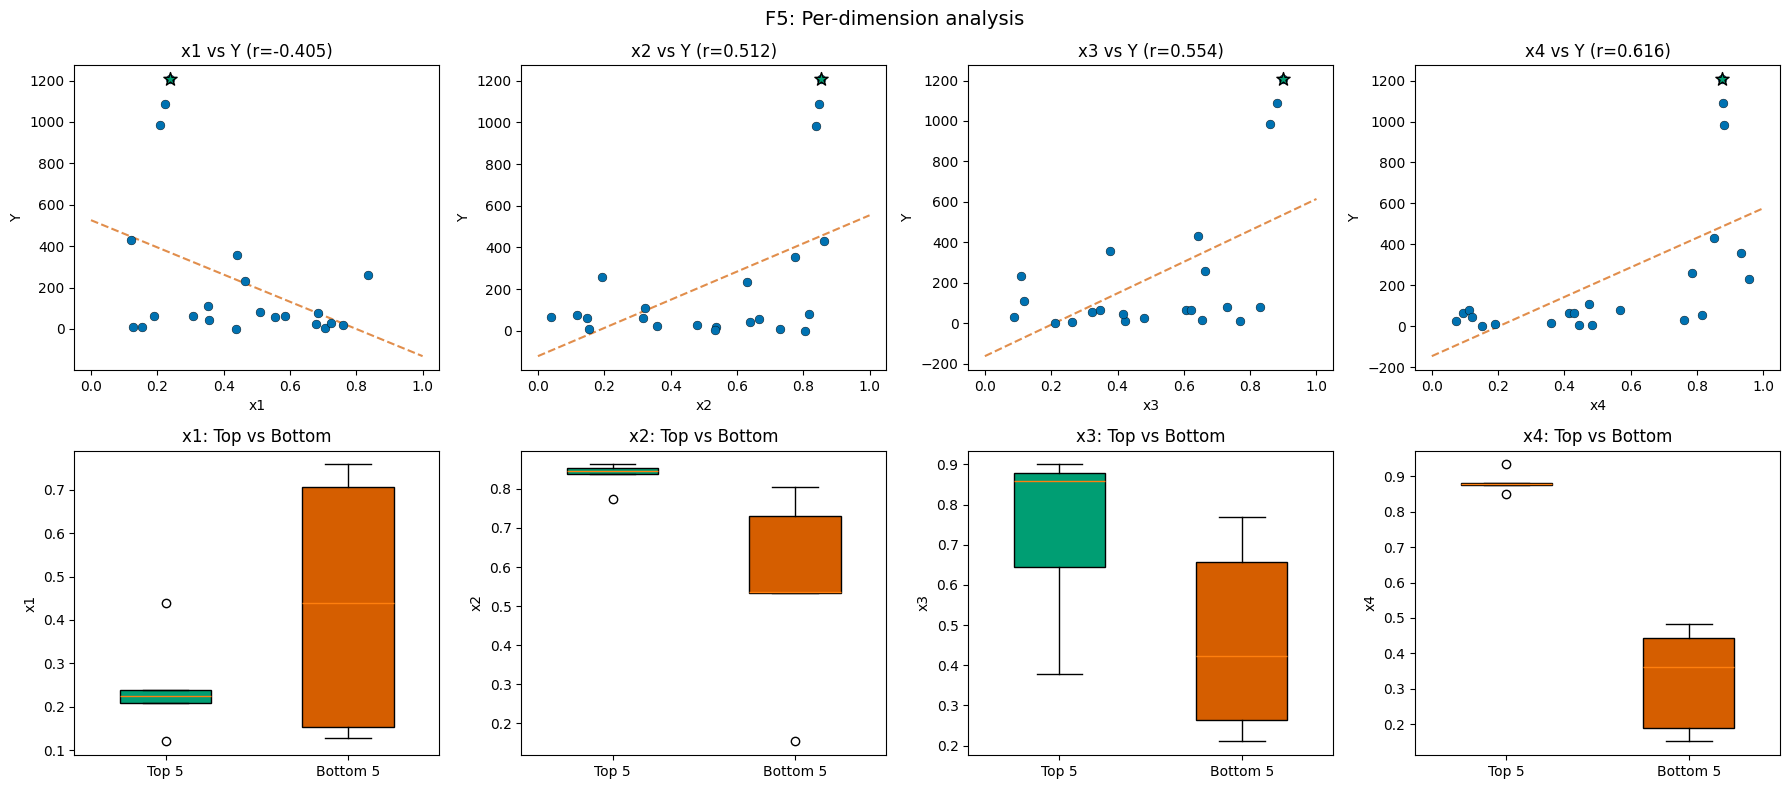

In [32]:
# F5 — Per-dimension correlations + boxplots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
dim_names = ["x1", "x2", "x3", "x4"]

for d in range(4):
    ax = axes[0, d]
    ax.scatter(
        X[:, d], Y, c=COLORS[0], s=40, edgecolors="black", linewidth=0.3, zorder=5
    )
    ax.scatter(
        X[best_idx, d],
        Y[best_idx],
        c=COLORS[2],
        s=100,
        edgecolors="black",
        linewidth=1,
        zorder=6,
        marker="*",
    )
    r = np.corrcoef(X[:, d], Y)[0, 1]
    z = np.polyfit(X[:, d], Y, 1)
    ax.plot([0, 1], [z[1], z[0] + z[1]], color=COLORS[1], linestyle="--", alpha=0.7)
    ax.set_xlabel(dim_names[d])
    ax.set_ylabel("Y")
    ax.set_title(f"{dim_names[d]} vs Y (r={r:.3f})")

top5 = np.argsort(Y)[-5:]
bot5 = np.argsort(Y)[:5]
for d in range(4):
    ax = axes[1, d]
    bp = ax.boxplot(
        [X[top5, d], X[bot5, d]],
        tick_labels=["Top 5", "Bottom 5"],
        patch_artist=True,
        widths=0.5,
    )
    bp["boxes"][0].set_facecolor(COLORS[2])
    bp["boxes"][1].set_facecolor(COLORS[1])
    ax.set_ylabel(dim_names[d])
    ax.set_title(f"{dim_names[d]}: Top vs Bottom")

plt.suptitle("F5: Per-dimension analysis", fontsize=14)
plt.tight_layout()
plt.savefig(
    "../plots/week_03/function_5_correlations.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [33]:
# F5 — Feature importance & robustness
from sklearn.ensemble import RandomForestRegressor as RF_imp
from sklearn.linear_model import LinearRegression

rf_all = RF_imp(n_estimators=200, random_state=42).fit(X, Y)
imp_all = rf_all.feature_importances_
mask_nb = np.arange(n_pts) != best_idx
rf_nb = RF_imp(n_estimators=200, random_state=42).fit(X[mask_nb], Y[mask_nb])
imp_nb = rf_nb.feature_importances_
corrs = [np.corrcoef(X[:, d], Y)[0, 1] for d in range(4)]
lr = LinearRegression().fit(X, Y)

print(
    f"{'Dim':<5} {'Corr':>8} {'RF(all)':>10} {'RF(no best)':>12} {'Drop%':>8} {'Linear':>8} {'Robust?':>8}"
)
print("-" * 70)
for d in range(4):
    drop = (1 - imp_nb[d] / imp_all[d]) * 100 if imp_all[d] > 0 else 0
    robust = "YES" if abs(drop) < 50 else "NO"
    print(
        f"x{d + 1:<4} {corrs[d]:>8.3f} {imp_all[d]:>10.3f} {imp_nb[d]:>12.3f} {drop:>7.1f}% {lr.coef_[d]:>8.1f} {robust:>8}"
    )

Dim       Corr    RF(all)  RF(no best)    Drop%   Linear  Robust?
----------------------------------------------------------------------
x1      -0.405      0.022        0.031   -41.9%   -250.5      YES
x2       0.512      0.175        0.160     8.2%    366.3      YES
x3       0.554      0.631        0.548    13.0%    668.9      YES
x4       0.616      0.173        0.261   -50.5%    583.2       NO


In [34]:
# F5 — GridSearchCV model fitting (LOOCV)
loo = LeaveOneOut()
baseline_rmse = Y.std()
print(f"Baseline RMSE (Y.std): {baseline_rmse:.2f}\n")

results_f5 = []
for name, model, params in [
    ("Ridge", Ridge(), {"alpha": [0.01, 0.1, 1.0, 10, 100]}),
    (
        "KNN",
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    ),
    (
        "RF",
        RandomForestRegressor(random_state=42),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    ),
    (
        "SVR",
        SVR(),
        {"C": [0.1, 1, 10, 100], "kernel": ["rbf"], "gamma": ["scale", "auto"]},
    ),
    (
        "GB",
        GradientBoostingRegressor(random_state=42),
        {
            "max_depth": [2, 3, 5],
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.3],
        },
    ),
]:
    grid = GridSearchCV(
        model, params, cv=loo, scoring="neg_mean_squared_error", refit=True
    )
    grid.fit(X, Y)
    rmse = np.sqrt(-grid.best_score_)
    results_f5.append((name, grid.best_params_, rmse, grid))

gp = GaussianProcessRegressor(
    kernel=Matern(nu=2.5), random_state=42, n_restarts_optimizer=5
)
scores = cross_val_score(gp, X, Y, cv=loo, scoring="neg_mean_squared_error")
results_f5.append(("GP-Matern", {}, np.sqrt(-scores.mean()), None))

print(f"{'Model':<12} {'RMSE':>8} {'Improvement':>12} {'Beats?':>8} {'Best Params'}")
print("-" * 75)
for name, params, rmse, _ in sorted(results_f5, key=lambda x: x[2]):
    imp = (1 - rmse / baseline_rmse) * 100
    beats = "YES" if imp > 0 else "no"
    p_str = str(params) if params else ""
    print(f"{name:<12} {rmse:>8.2f} {imp:>11.1f}% {beats:>8}  {p_str}")

print(f"\nAll {len(results_f5)} models beat baseline — strong signal")

Baseline RMSE (Y.std): 360.06

Model            RMSE  Improvement   Beats? Best Params
---------------------------------------------------------------------------
KNN            115.31        68.0%      YES  {'n_neighbors': 7, 'weights': 'distance'}
GP-Matern      142.51        60.4%      YES  
GB             158.62        55.9%      YES  {'learning_rate': 0.3, 'max_depth': 2, 'n_estimators': 200}
RF             170.99        52.5%      YES  {'max_depth': 3, 'n_estimators': 50}
Ridge          215.16        40.2%      YES  {'alpha': 0.1}
SVR            264.31        26.6%      YES  {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}

All 6 models beat baseline — strong signal


In [35]:
# F5 — Model suggestions & convergence
np.random.seed(42)
candidates = np.random.uniform(0.02, 0.98, (200000, 4))

all_sugg = []
print(f"{'Model':<12} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'Imp%':>7} {'Bnd':>5}")
print("-" * 55)
for name, params, rmse, grid_obj in results_f5:
    imp = (1 - rmse / baseline_rmse) * 100
    if imp <= 0:
        continue
    if grid_obj is not None:
        pred = grid_obj.predict(candidates)
    else:
        gp_fit = GaussianProcessRegressor(
            kernel=Matern(nu=2.5), random_state=42, n_restarts_optimizer=5
        )
        gp_fit.fit(X, Y)
        pred = gp_fit.predict(candidates)
    best_cand = candidates[np.argmax(pred)]
    on_bnd = any(v < 0.02 or v > 0.98 for v in best_cand)
    bnd = "SKIP" if on_bnd else "ok"
    print(
        f"{name:<12} {best_cand[0]:>7.4f} {best_cand[1]:>7.4f} {best_cand[2]:>7.4f} {best_cand[3]:>7.4f} {imp:>6.1f}% {bnd:>5}"
    )
    if not on_bnd:
        all_sugg.append((name, best_cand, rmse))

# Exclude Ridge (linear extrapolator)
suggestions_f5 = [s for s in all_sugg if s[0] != "Ridge"]
sugg_arr = np.array([s[1] for s in suggestions_f5])
rmse_arr = np.array([s[2] for s in suggestions_f5])

print(f"\n=== Convergence ({len(suggestions_f5)} non-linear models) ===")
for d in range(4):
    spread = sugg_arr[:, d].max() - sugg_arr[:, d].min()
    strength = "STRONG" if spread < 0.2 else "moderate" if spread < 0.4 else "weak"
    print(
        f"  x{d + 1}: spread={spread:.4f} ({strength}) "
        f"[{sugg_arr[:, d].min():.4f}, {sugg_arr[:, d].max():.4f}]"
    )

w = 1.0 / rmse_arr
w /= w.sum()
weighted = (sugg_arr * w[:, None]).sum(axis=0)
print(f"\n  RMSE-weighted: ({', '.join(f'{v:.4f}' for v in weighted)})")

# Gradient extrapolation for comparison
top2 = np.argsort(Y)[-2:][::-1]
step = X[top2[0]] - X[top2[1]]
grad_extrap = np.clip(X[top2[0]] + step, 0.02, 0.98)
print(f"  Gradient extrap: ({', '.join(f'{v:.4f}' for v in grad_extrap)})")
print(
    f"  Agreement: {np.linalg.norm(weighted - grad_extrap):.4f} (models & gradient converge)"
)

Model             x1      x2      x3      x4    Imp%   Bnd
-------------------------------------------------------
Ridge         0.0254  0.9662  0.9612  0.9763   40.2%    ok
KNN           0.2194  0.8588  0.8959  0.8627   68.0%    ok
RF            0.2854  0.9490  0.9722  0.8696   52.5%    ok
SVR           0.2396  0.8553  0.8203  0.9436   26.6%    ok
GB            0.3530  0.8618  0.9240  0.8712   55.9%    ok
GP-Matern     0.2637  0.8591  0.9373  0.8638   60.4%    ok

=== Convergence (5 non-linear models) ===
  x1: spread=0.1336 (STRONG) [0.2194, 0.3530]
  x2: spread=0.0937 (STRONG) [0.8553, 0.9490]
  x3: spread=0.1519 (STRONG) [0.8203, 0.9722]
  x4: spread=0.0809 (STRONG) [0.8627, 0.9436]

  RMSE-weighted: (0.2705, 0.8758, 0.9157, 0.8756)
  Gradient extrap: (0.2546, 0.8619, 0.9201, 0.8707)
  Agreement: 0.0221 (models & gradient converge)


In [36]:
# F5 — Week 03 query
# Models and gradient extrapolation agree — use RMSE-weighted average
next_query_5 = weighted.copy()

print(f"F5 Week 03 query: [{', '.join(f'{v:.6f}' for v in next_query_5)}]")
print(f"Method: RMSE-weighted average of {len(suggestions_f5)} non-linear models")
print(f"Models used: {[s[0] for s in suggestions_f5]}")
print(f"Current best: pt{best_idx + 1} Y = {Y.max():.2f}")
print(
    f"Boundary check: {'FAIL' if any(v < 0.02 or v > 0.98 for v in next_query_5) else 'OK'}"
)

F5 Week 03 query: [0.270475, 0.875752, 0.915748, 0.875603]
Method: RMSE-weighted average of 5 non-linear models
Models used: ['KNN', 'RF', 'SVR', 'GB', 'GP-Matern']
Current best: pt22 Y = 1206.76
Boundary check: OK


### F5 Decision — Week 03

**Week 02 result: NEW BEST!** pt22 at (0.24, 0.85, 0.90, 0.87) gave Y = 1206.76, up from 1088.86. The perturbation in the climbing direction worked (+118 points).

**Feature importance:** x3 dominates (63%, r=0.55), robust. x4 borderline (50% drop without best). x1 has negative correlation (lower = better).

**Models:** ALL 6/6 beat baseline. KNN best (68%), GP-Matern (60%), GB (56%), RF (53%).

**Convergence (non-linear models):** STRONG on ALL 4 dimensions. Models and gradient extrapolation agree (distance 0.02) — very high confidence.

**Strategy:** RMSE-weighted average. Continues the climbing trajectory (increasing x1, x3) while letting the models refine x2 and x4 based on all 22 data points.

**Next week:** If Y improves again, continue climbing. If it plateaus, the peak is near — try smaller perturbation. If it drops, overshot — try midpoint between last two bests.

## Function 6

In [37]:
# Function 6 — Data overview (5D)
X, Y = load_function(6)
n_pts = len(Y)
best_idx = np.argmax(Y)
w02_idx = n_pts - 1
prev_best = np.argmax(Y[:w02_idx])

print(f"F6: {n_pts} points, {X.shape[1]}D")
print(f"Best Y: {Y.max():.4f} at pt{best_idx + 1}")
print(
    f"Week 02 pt{w02_idx + 1}: Y={Y[w02_idx]:.4f} — "
    f"{'NEW BEST!' if Y[w02_idx] > Y[prev_best] else 'DID NOT improve'}"
)
print()

order = np.argsort(Y)[::-1][:8]
print(f"{'Pt':>4} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'x5':>7} {'Y':>9}")
print("-" * 55)
for i in order:
    m = " <--" if i == best_idx else ""
    print(
        f"pt{i + 1:>2} {X[i, 0]:>7.4f} {X[i, 1]:>7.4f} {X[i, 2]:>7.4f} {X[i, 3]:>7.4f} {X[i, 4]:>7.4f} {Y[i]:>9.4f}{m}"
    )

Function 6: 22 points, 5D, best y = -0.4370
F6: 22 points, 5D
Best Y: -0.4370 at pt21
Week 02 pt22: Y=-0.6086 — DID NOT improve

  Pt      x1      x2      x3      x4      x5         Y
-------------------------------------------------------
pt21  0.5160  0.3513  0.5119  0.6916  0.1596   -0.4370 <--
pt22  0.2838  0.2587  0.5077  0.9687  0.0439   -0.6086
pt 1  0.7282  0.1547  0.7326  0.6940  0.0564   -0.7143
pt 5  0.6188  0.3318  0.1873  0.7562  0.3288   -0.8292
pt18  0.7829  0.5363  0.4433  0.8597  0.0103   -0.9358
pt11  0.5368  0.3088  0.4119  0.3882  0.5225   -1.1448
pt 2  0.2424  0.8441  0.5778  0.6790  0.5020   -1.2100
pt 7  0.1451  0.8967  0.8963  0.7263  0.2363   -1.2338


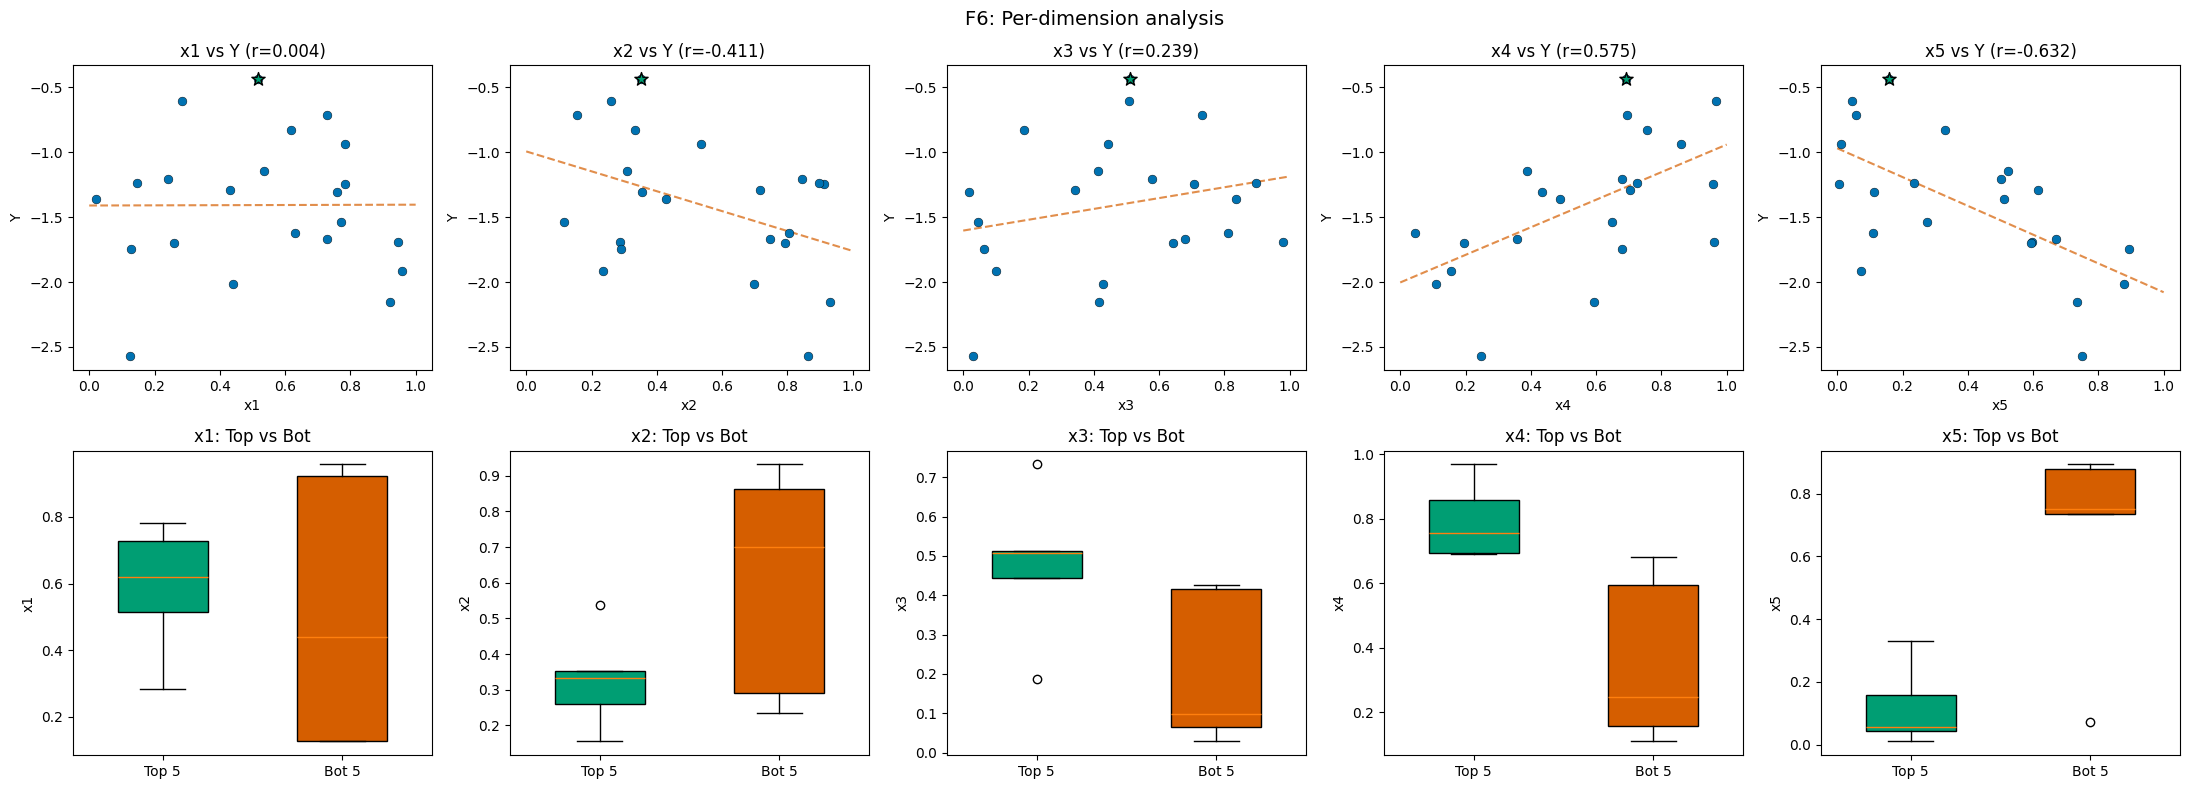

In [38]:
# F6 — Per-dimension correlations + boxplots
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
dim_names = ["x1", "x2", "x3", "x4", "x5"]

for d in range(5):
    ax = axes[0, d]
    ax.scatter(
        X[:, d], Y, c=COLORS[0], s=40, edgecolors="black", linewidth=0.3, zorder=5
    )
    ax.scatter(
        X[best_idx, d],
        Y[best_idx],
        c=COLORS[2],
        s=100,
        edgecolors="black",
        linewidth=1,
        zorder=6,
        marker="*",
    )
    r = np.corrcoef(X[:, d], Y)[0, 1]
    z = np.polyfit(X[:, d], Y, 1)
    ax.plot([0, 1], [z[1], z[0] + z[1]], color=COLORS[1], linestyle="--", alpha=0.7)
    ax.set_xlabel(dim_names[d])
    ax.set_ylabel("Y")
    ax.set_title(f"{dim_names[d]} vs Y (r={r:.3f})")

top5 = np.argsort(Y)[-5:]
bot5 = np.argsort(Y)[:5]
for d in range(5):
    ax = axes[1, d]
    bp = ax.boxplot(
        [X[top5, d], X[bot5, d]],
        tick_labels=["Top 5", "Bot 5"],
        patch_artist=True,
        widths=0.5,
    )
    bp["boxes"][0].set_facecolor(COLORS[2])
    bp["boxes"][1].set_facecolor(COLORS[1])
    ax.set_ylabel(dim_names[d])
    ax.set_title(f"{dim_names[d]}: Top vs Bot")

plt.suptitle("F6: Per-dimension analysis", fontsize=14)
plt.tight_layout()
plt.savefig(
    "../plots/week_03/function_6_correlations.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [39]:
# F6 — Feature importance & robustness
from sklearn.ensemble import RandomForestRegressor as RF_imp
from sklearn.linear_model import LinearRegression

rf_all = RF_imp(n_estimators=200, random_state=42).fit(X, Y)
imp_all = rf_all.feature_importances_
mask_nb = np.arange(n_pts) != best_idx
rf_nb = RF_imp(n_estimators=200, random_state=42).fit(X[mask_nb], Y[mask_nb])
imp_nb = rf_nb.feature_importances_
corrs = [np.corrcoef(X[:, d], Y)[0, 1] for d in range(5)]
lr = LinearRegression().fit(X, Y)

print(
    f"{'Dim':<5} {'Corr':>8} {'RF(all)':>10} {'RF(no best)':>12} {'Drop%':>8} {'Linear':>8} {'Robust?':>8}"
)
print("-" * 70)
for d in range(5):
    drop = (1 - imp_nb[d] / imp_all[d]) * 100 if imp_all[d] > 0 else 0
    robust = "YES" if abs(drop) < 50 else "NO"
    print(
        f"x{d + 1:<4} {corrs[d]:>8.3f} {imp_all[d]:>10.3f} {imp_nb[d]:>12.3f} {drop:>7.1f}% {lr.coef_[d]:>8.3f} {robust:>8}"
    )

Dim       Corr    RF(all)  RF(no best)    Drop%   Linear  Robust?
----------------------------------------------------------------------
x1       0.004      0.075        0.079    -6.5%   -0.488      YES
x2      -0.411      0.128        0.118     7.7%   -0.561      YES
x3       0.239      0.051        0.061   -20.1%    0.322      YES
x4       0.575      0.344        0.305    11.3%    0.644      YES
x5      -0.632      0.402        0.436    -8.4%   -0.914      YES


In [40]:
# F6 — GridSearchCV model fitting (LOOCV)
loo = LeaveOneOut()
baseline_rmse = Y.std()
print(f"Baseline RMSE (Y.std): {baseline_rmse:.4f}\n")

results_f6 = []
for name, model, params in [
    ("Ridge", Ridge(), {"alpha": [0.01, 0.1, 1.0, 10, 100]}),
    (
        "KNN",
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    ),
    (
        "RF",
        RandomForestRegressor(random_state=42),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    ),
    (
        "SVR",
        SVR(),
        {"C": [0.1, 1, 10, 100], "kernel": ["rbf"], "gamma": ["scale", "auto"]},
    ),
    (
        "GB",
        GradientBoostingRegressor(random_state=42),
        {
            "max_depth": [2, 3, 5],
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.3],
        },
    ),
]:
    grid = GridSearchCV(
        model, params, cv=loo, scoring="neg_mean_squared_error", refit=True
    )
    grid.fit(X, Y)
    rmse = np.sqrt(-grid.best_score_)
    results_f6.append((name, grid.best_params_, rmse, grid))

gp = GaussianProcessRegressor(
    kernel=Matern(nu=2.5), random_state=42, n_restarts_optimizer=5
)
scores = cross_val_score(gp, X, Y, cv=loo, scoring="neg_mean_squared_error")
results_f6.append(("GP-Matern", {}, np.sqrt(-scores.mean()), None))

print(f"{'Model':<12} {'RMSE':>8} {'Improvement':>12} {'Beats?':>8} {'Best Params'}")
print("-" * 75)
for name, params, rmse, _ in sorted(results_f6, key=lambda x: x[2]):
    imp = (1 - rmse / baseline_rmse) * 100
    beats = "YES" if imp > 0 else "no"
    p_str = str(params) if params else ""
    print(f"{name:<12} {rmse:>8.4f} {imp:>11.1f}% {beats:>8}  {p_str}")

print(f"\nSVR dominates — trust its suggestion")

Baseline RMSE (Y.std): 0.5120

Model            RMSE  Improvement   Beats? Best Params
---------------------------------------------------------------------------
SVR            0.2303        55.0%      YES  {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
GP-Matern      0.3295        35.6%      YES  
KNN            0.3466        32.3%      YES  {'n_neighbors': 3, 'weights': 'uniform'}
GB             0.3599        29.7%      YES  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
RF             0.3648        28.7%      YES  {'max_depth': 5, 'n_estimators': 100}
Ridge          0.3911        23.6%      YES  {'alpha': 1.0}

SVR dominates — trust its suggestion


In [41]:
# F6 — Model suggestions & convergence
np.random.seed(42)
candidates = np.random.uniform(0.02, 0.98, (200000, 5))

all_sugg = []
print(
    f"{'Model':<12} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'x5':>7} {'Imp%':>7} {'Bnd':>5}"
)
print("-" * 65)
for name, params, rmse, grid_obj in results_f6:
    imp = (1 - rmse / baseline_rmse) * 100
    if imp <= 0:
        continue
    if grid_obj is not None:
        pred = grid_obj.predict(candidates)
    else:
        gp_fit = GaussianProcessRegressor(
            kernel=Matern(nu=2.5), random_state=42, n_restarts_optimizer=5
        )
        gp_fit.fit(X, Y)
        pred = gp_fit.predict(candidates)
    best_cand = candidates[np.argmax(pred)]
    on_bnd = any(v < 0.02 or v > 0.98 for v in best_cand)
    bnd = "SKIP" if on_bnd else "ok"
    print(
        f"{name:<12} {best_cand[0]:>7.4f} {best_cand[1]:>7.4f} {best_cand[2]:>7.4f} {best_cand[3]:>7.4f} {best_cand[4]:>7.4f} {imp:>6.1f}% {bnd:>5}"
    )
    if not on_bnd:
        all_sugg.append((name, best_cand, rmse))

# Exclude Ridge
suggestions_f6 = [s for s in all_sugg if s[0] != "Ridge"]
sugg_arr = np.array([s[1] for s in suggestions_f6])
rmse_arr = np.array([s[2] for s in suggestions_f6])

print(f"\n=== Convergence ({len(suggestions_f6)} non-linear models) ===")
for d in range(5):
    sp = sugg_arr[:, d].max() - sugg_arr[:, d].min()
    strength = "STRONG" if sp < 0.2 else "moderate" if sp < 0.4 else "weak"
    print(
        f"  x{d + 1}: [{sugg_arr[:, d].min():.4f}, {sugg_arr[:, d].max():.4f}] spread={sp:.4f} ({strength})"
    )

w = 1.0 / rmse_arr
w /= w.sum()
weighted = (sugg_arr * w[:, None]).sum(axis=0)
print(f"\n  RMSE-weighted: ({', '.join(f'{v:.4f}' for v in weighted)})")

# Centroid of top 4
top4 = np.argsort(Y)[-4:]
top4_w = Y[top4] - Y[top4].min() + 0.001
top4_w /= top4_w.sum()
centroid = (X[top4] * top4_w[:, None]).sum(axis=0)
print(f"  Centroid (top 4): ({', '.join(f'{v:.4f}' for v in centroid)})")

Model             x1      x2      x3      x4      x5    Imp%   Bnd
-----------------------------------------------------------------
Ridge         0.0811  0.0455  0.9345  0.9528  0.0406   23.6%    ok
KNN           0.3474  0.1289  0.9077  0.8622  0.2676   32.3%    ok
RF            0.3976  0.3375  0.5030  0.6899  0.0840   28.7%    ok
SVR           0.3870  0.3734  0.5139  0.8531  0.0470   55.0%    ok
GB            0.4855  0.3091  0.5985  0.7829  0.1516   29.7%    ok
GP-Matern     0.4555  0.3374  0.4455  0.7062  0.0833   35.6%    ok

=== Convergence (5 non-linear models) ===
  x1: [0.3474, 0.4855] spread=0.1381 (STRONG)
  x2: [0.1289, 0.3734] spread=0.2445 (moderate)
  x3: [0.4455, 0.9077] spread=0.4622 (weak)
  x4: [0.6899, 0.8622] spread=0.1723 (STRONG)
  x5: [0.0470, 0.2676] spread=0.2206 (moderate)

  RMSE-weighted: (0.4121, 0.3042, 0.5857, 0.7858, 0.1191)
  Centroid (top 4): (0.4794, 0.2921, 0.5452, 0.7760, 0.1085)


In [42]:
# F6 — Week 03 query
# SVR dominates at ~55% — trust its suggestion
svr_sugg = [s for s in suggestions_f6 if s[0] == "SVR"]
if svr_sugg:
    next_query_6 = svr_sugg[0][1].copy()
else:
    next_query_6 = weighted.copy()

print(f"F6 Week 03 query: [{', '.join(f'{v:.6f}' for v in next_query_6)}]")
print(
    f"Method: SVR suggestion (dominant at "
    f"{(1 - svr_sugg[0][2] / baseline_rmse) * 100:.1f}% improvement)"
)
print(f"Current best: pt{best_idx + 1} Y = {Y.max():.4f}")
print(
    f"Boundary check: {'FAIL' if any(v < 0.02 or v > 0.98 for v in next_query_6) else 'OK'}"
)

F6 Week 03 query: [0.387036, 0.373428, 0.513896, 0.853071, 0.046985]
Method: SVR suggestion (dominant at 55.0% improvement)
Current best: pt21 Y = -0.4370
Boundary check: OK


### F6 Decision — Week 03

**Week 02 result:** pt22 gave Y = -0.609 — did NOT beat pt21 (-0.437). The SVR suggestion from week 02 pushed x4 too high (0.97) and x5 too low (0.04).

**Feature importance:** x5 (40%, r=-0.63) and x4 (34%, r=0.58) dominate. All robust. Low x5 and high x4 → higher Y.

**Models:** ALL 6/6 beat baseline. **SVR dominates at 55%** (next: GP 36%, KNN 32%).

**Convergence:** x1 STRONG, x4 STRONG, x2/x5 moderate, x3 weak. SVR and centroid agree on the general region.

**Strategy:** Trust SVR — it's more conservative than week 02's suggestion (x4=0.85 vs 0.97, x5=0.05 vs 0.04) while still pushing in the right direction.

**Next week:** If Y improves, SVR is calibrated. If not, try centroid of top 4 as alternative.

## Function 7

In [43]:
# Function 7 — Data overview (6D)
X, Y = load_function(7)
n_pts = len(Y)
best_idx = np.argmax(Y)
w02_idx = n_pts - 1
prev_best = np.argmax(Y[:w02_idx])

print(f"F7: {n_pts} points, {X.shape[1]}D")
print(f"Best Y: {Y.max():.4f} at pt{best_idx + 1}")
print(
    f"Week 02 pt{w02_idx + 1}: Y={Y[w02_idx]:.4f} — "
    f"{'NEW BEST!' if Y[w02_idx] > Y[prev_best] else 'DID NOT improve'}"
)
print()

order = np.argsort(Y)[::-1][:8]
dim_names = [f"x{d + 1}" for d in range(6)]
header = f"{'Pt':>4} " + " ".join(f"{d:>7}" for d in dim_names) + f" {'Y':>9}"
print(header)
print("-" * len(header))
for i in order:
    vals = " ".join(f"{X[i, d]:>7.4f}" for d in range(6))
    m = " <--" if i == best_idx else ""
    print(f"pt{i + 1:>2} {vals} {Y[i]:>9.4f}{m}")

Function 7: 32 points, 6D, best y = 1.3650
F7: 32 points, 6D
Best Y: 1.3650 at pt7
Week 02 pt32: Y=0.9318 — DID NOT improve

  Pt      x1      x2      x3      x4      x5      x6         Y
--------------------------------------------------------------
pt 7  0.0579  0.4917  0.2474  0.2181  0.4204  0.7310    1.3650 <--
pt31  0.1291  0.4626  0.2670  0.2370  0.4030  0.9000    1.1246
pt32  0.0640  0.4820  0.2810  0.1230  0.4880  0.6760    0.9318
pt25  0.8816  0.2045  0.4145  0.4204  0.2649  0.7307    0.6751
pt15  0.1486  0.0339  0.7288  0.3161  0.0218  0.5169    0.6115
pt 1  0.2726  0.3245  0.8971  0.8330  0.1541  0.7959    0.6044
pt 2  0.5430  0.9247  0.3416  0.6465  0.7184  0.3431    0.5628
pt26  0.0666  0.5280  0.8161  0.9610  0.0865  0.7778    0.5165


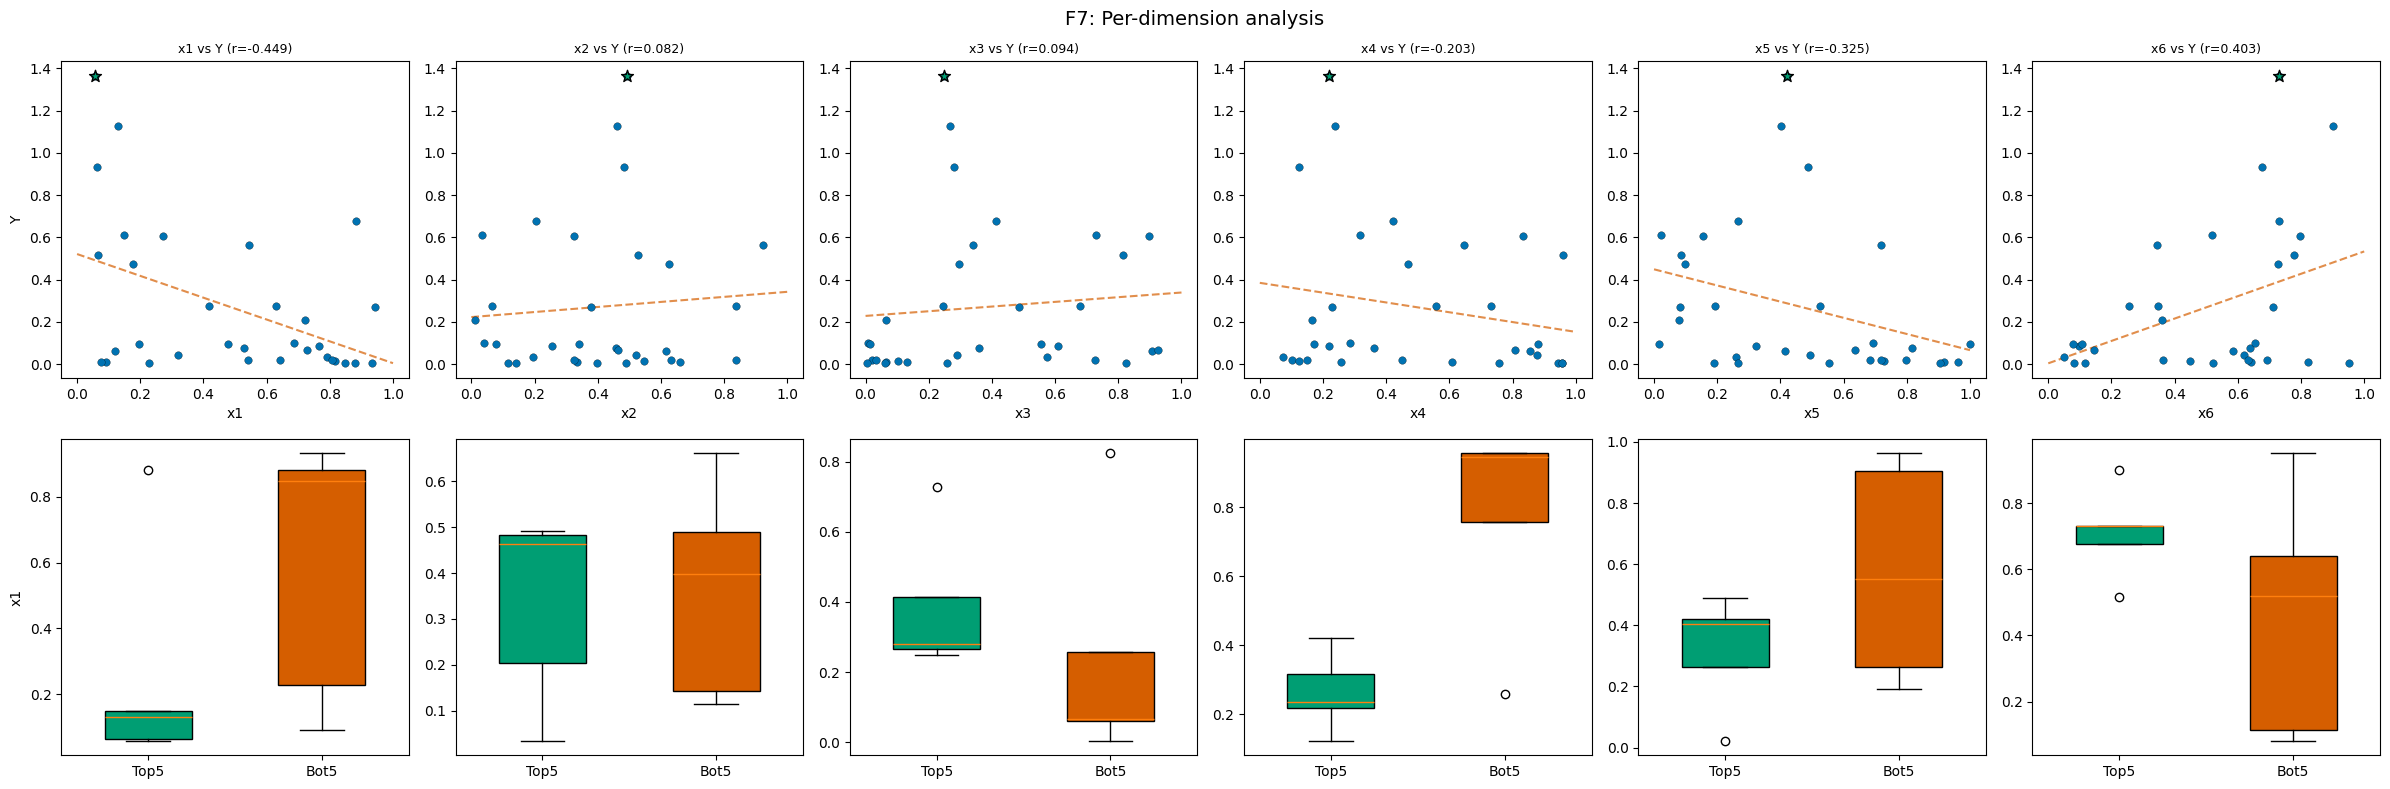

In [44]:
# F7 — Per-dimension correlations + boxplots
fig, axes = plt.subplots(2, 6, figsize=(24, 8))

for d in range(6):
    ax = axes[0, d]
    ax.scatter(
        X[:, d], Y, c=COLORS[0], s=30, edgecolors="black", linewidth=0.2, zorder=5
    )
    ax.scatter(
        X[best_idx, d],
        Y[best_idx],
        c=COLORS[2],
        s=80,
        edgecolors="black",
        linewidth=1,
        zorder=6,
        marker="*",
    )
    r = np.corrcoef(X[:, d], Y)[0, 1]
    z = np.polyfit(X[:, d], Y, 1)
    ax.plot([0, 1], [z[1], z[0] + z[1]], color=COLORS[1], linestyle="--", alpha=0.7)
    ax.set_xlabel(f"x{d + 1}")
    ax.set_ylabel("Y" if d == 0 else "")
    ax.set_title(f"x{d + 1} vs Y (r={r:.3f})", fontsize=9)

top5 = np.argsort(Y)[-5:]
bot5 = np.argsort(Y)[:5]
for d in range(6):
    ax = axes[1, d]
    bp = ax.boxplot(
        [X[top5, d], X[bot5, d]],
        tick_labels=["Top5", "Bot5"],
        patch_artist=True,
        widths=0.5,
    )
    bp["boxes"][0].set_facecolor(COLORS[2])
    bp["boxes"][1].set_facecolor(COLORS[1])
    ax.set_ylabel(f"x{d + 1}" if d == 0 else "")

plt.suptitle("F7: Per-dimension analysis", fontsize=14)
plt.tight_layout()
plt.savefig(
    "../plots/week_03/function_7_correlations.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [45]:
# F7 — Feature importance & robustness
from sklearn.ensemble import RandomForestRegressor as RF_imp
from sklearn.linear_model import LinearRegression

rf_all = RF_imp(n_estimators=200, random_state=42).fit(X, Y)
imp_all = rf_all.feature_importances_
mask_nb = np.arange(n_pts) != best_idx
rf_nb = RF_imp(n_estimators=200, random_state=42).fit(X[mask_nb], Y[mask_nb])
imp_nb = rf_nb.feature_importances_
corrs = [np.corrcoef(X[:, d], Y)[0, 1] for d in range(6)]
lr = LinearRegression().fit(X, Y)

print(
    f"{'Dim':<5} {'Corr':>8} {'RF(all)':>10} {'RF(no best)':>12} {'Drop%':>8} {'Linear':>8} {'Robust?':>8}"
)
print("-" * 70)
for d in range(6):
    drop = (1 - imp_nb[d] / imp_all[d]) * 100 if imp_all[d] > 0 else 0
    robust = "YES" if abs(drop) < 50 else "NO"
    print(
        f"x{d + 1:<4} {corrs[d]:>8.3f} {imp_all[d]:>10.3f} {imp_nb[d]:>12.3f} {drop:>7.1f}% {lr.coef_[d]:>8.3f} {robust:>8}"
    )

Dim       Corr    RF(all)  RF(no best)    Drop%   Linear  Robust?
----------------------------------------------------------------------
x1      -0.449      0.367        0.210    42.9%   -0.402      YES
x2       0.082      0.091        0.139   -51.7%    0.216       NO
x3       0.094      0.071        0.087   -21.3%   -0.050      YES
x4      -0.203      0.064        0.060     7.4%   -0.237      YES
x5      -0.325      0.143        0.233   -63.2%   -0.476       NO
x6       0.403      0.263        0.273    -3.5%    0.314      YES


In [46]:
# F7 — GridSearchCV model fitting (LOOCV)
loo = LeaveOneOut()
baseline_rmse = Y.std()
print(f"Baseline RMSE (Y.std): {baseline_rmse:.4f}\n")

results_f7 = []
for name, model, params in [
    ("Ridge", Ridge(), {"alpha": [0.01, 0.1, 1.0, 10, 100]}),
    (
        "KNN",
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    ),
    (
        "RF",
        RandomForestRegressor(random_state=42),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    ),
    (
        "SVR",
        SVR(),
        {"C": [0.1, 1, 10, 100], "kernel": ["rbf"], "gamma": ["scale", "auto"]},
    ),
    (
        "GB",
        GradientBoostingRegressor(random_state=42),
        {
            "max_depth": [2, 3, 5],
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.3],
        },
    ),
]:
    grid = GridSearchCV(
        model, params, cv=loo, scoring="neg_mean_squared_error", refit=True
    )
    grid.fit(X, Y)
    rmse = np.sqrt(-grid.best_score_)
    results_f7.append((name, grid.best_params_, rmse, grid))

gp = GaussianProcessRegressor(
    kernel=Matern(nu=2.5), random_state=42, n_restarts_optimizer=5
)
scores = cross_val_score(gp, X, Y, cv=loo, scoring="neg_mean_squared_error")
results_f7.append(("GP-Matern", {}, np.sqrt(-scores.mean()), None))

print(f"{'Model':<12} {'RMSE':>8} {'Improvement':>12} {'Beats?':>8} {'Best Params'}")
print("-" * 75)
for name, params, rmse, _ in sorted(results_f7, key=lambda x: x[2]):
    imp = (1 - rmse / baseline_rmse) * 100
    beats = "YES" if imp > 0 else "no"
    p_str = str(params) if params else ""
    print(f"{name:<12} {rmse:>8.4f} {imp:>11.1f}% {beats:>8}  {p_str}")

Baseline RMSE (Y.std): 0.3528

Model            RMSE  Improvement   Beats? Best Params
---------------------------------------------------------------------------
SVR            0.2332        33.9%      YES  {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
KNN            0.2336        33.8%      YES  {'n_neighbors': 5, 'weights': 'distance'}
GP-Matern      0.2844        19.4%      YES  
Ridge          0.3170        10.1%      YES  {'alpha': 1.0}
GB             0.3336         5.4%      YES  {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 50}
RF             0.3371         4.4%      YES  {'max_depth': 5, 'n_estimators': 100}


In [47]:
# F7 — Model suggestions & convergence
np.random.seed(42)
candidates = np.random.uniform(0.02, 0.98, (200000, 6))

all_sugg = []
print(
    f"{'Model':<10} "
    + " ".join(f"{'x' + str(d + 1):>7}" for d in range(6))
    + f" {'Imp%':>7} {'Bnd':>5}"
)
print("-" * 70)
for name, params, rmse, grid_obj in results_f7:
    imp = (1 - rmse / baseline_rmse) * 100
    if imp <= 0:
        continue
    if grid_obj is not None:
        pred = grid_obj.predict(candidates)
    else:
        gp_fit = GaussianProcessRegressor(
            kernel=Matern(nu=2.5), random_state=42, n_restarts_optimizer=5
        )
        gp_fit.fit(X, Y)
        pred = gp_fit.predict(candidates)
    best_cand = candidates[np.argmax(pred)]
    on_bnd = any(v < 0.02 or v > 0.98 for v in best_cand)
    bnd = "SKIP" if on_bnd else "ok"
    vals = " ".join(f"{best_cand[d]:>7.4f}" for d in range(6))
    print(f"{name:<10} {vals} {imp:>6.1f}% {bnd:>5}")
    if not on_bnd:
        all_sugg.append((name, best_cand, rmse))

suggestions_f7 = [s for s in all_sugg if s[0] != "Ridge"]
sugg_arr = np.array([s[1] for s in suggestions_f7])
rmse_arr = np.array([s[2] for s in suggestions_f7])

print(f"\n=== Convergence ({len(suggestions_f7)} non-linear) ===")
for d in range(6):
    sp = sugg_arr[:, d].max() - sugg_arr[:, d].min()
    strength = "STRONG" if sp < 0.2 else "moderate" if sp < 0.4 else "weak"
    print(
        f"  x{d + 1}: [{sugg_arr[:, d].min():.4f}, {sugg_arr[:, d].max():.4f}] spread={sp:.4f} ({strength})"
    )

w = 1.0 / rmse_arr
w /= w.sum()
model_avg = (sugg_arr * w[:, None]).sum(axis=0)
print(f"\n  RMSE-weighted: ({', '.join(f'{v:.4f}' for v in model_avg)})")

# Centroid of top 4
top4 = np.argsort(Y)[-4:]
top4_w = Y[top4] - Y[top4].min() + 0.001
top4_w /= top4_w.sum()
centroid = (X[top4] * top4_w[:, None]).sum(axis=0)
print(f"  Centroid (top 4): ({', '.join(f'{v:.4f}' for v in centroid)})")

Model           x1      x2      x3      x4      x5      x6    Imp%   Bnd
----------------------------------------------------------------------
Ridge       0.0552  0.9160  0.1378  0.1203  0.0417  0.9600   10.1%    ok
KNN         0.0258  0.5277  0.2960  0.1900  0.4002  0.7259   33.8%    ok
RF          0.0457  0.4285  0.2653  0.2476  0.4211  0.8682    4.4%    ok
SVR         0.0534  0.3001  0.2620  0.1009  0.3293  0.9420   33.9%    ok
GB          0.0203  0.8670  0.0389  0.7475  0.3672  0.7287    5.4%    ok
GP-Matern   0.0291  0.3503  0.0662  0.3426  0.3583  0.7678   19.4%    ok

=== Convergence (5 non-linear) ===
  x1: [0.0203, 0.0534] spread=0.0331 (STRONG)
  x2: [0.3001, 0.8670] spread=0.5669 (weak)
  x3: [0.0389, 0.2960] spread=0.2571 (moderate)
  x4: [0.1009, 0.7475] spread=0.6466 (weak)
  x5: [0.3293, 0.4211] spread=0.0918 (STRONG)
  x6: [0.7259, 0.9420] spread=0.2161 (moderate)

  RMSE-weighted: (0.0354, 0.4791, 0.1954, 0.3006, 0.3732, 0.8092)
  Centroid (top 4): (0.0825, 0.4803, 0.

In [48]:
# F7 — Week 03 query
# Hybrid: centroid on weak/moderate dims, model consensus on STRONG dims
next_query_7 = centroid.copy()

# Override STRONG consensus dimensions with model average
for d in range(6):
    sp = sugg_arr[:, d].max() - sugg_arr[:, d].min()
    if sp < 0.2:  # STRONG
        next_query_7[d] = model_avg[d]

print(f"F7 Week 03 query: [{', '.join(f'{v:.6f}' for v in next_query_7)}]")
print(f"Method: Hybrid (centroid + model override on STRONG dims)")
print(f"\nPer-dimension breakdown:")
for d in range(6):
    sp = sugg_arr[:, d].max() - sugg_arr[:, d].min()
    strength = "STRONG" if sp < 0.2 else "moderate" if sp < 0.4 else "weak"
    source = "model" if sp < 0.2 else "centroid"
    print(f"  x{d + 1}: {next_query_7[d]:.4f} ({strength}, from {source})")
print(f"\nCurrent best: pt{best_idx + 1} Y = {Y.max():.4f}")
print(
    f"Boundary check: {'FAIL' if any(v < 0.02 or v > 0.98 for v in next_query_7) else 'OK'}"
)

F7 Week 03 query: [0.035368, 0.480332, 0.260021, 0.206835, 0.373160, 0.775247]
Method: Hybrid (centroid + model override on STRONG dims)

Per-dimension breakdown:
  x1: 0.0354 (STRONG, from model)
  x2: 0.4803 (weak, from centroid)
  x3: 0.2600 (moderate, from centroid)
  x4: 0.2068 (weak, from centroid)
  x5: 0.3732 (STRONG, from model)
  x6: 0.7752 (moderate, from centroid)

Current best: pt7 Y = 1.3650
Boundary check: OK


### F7 Decision — Week 03

**Week 02 result:** pt32 gave Y = 0.932 — did NOT beat pt7 (1.365).

**Feature importance:** x1 (37%, r=-0.45) and x6 (26%, r=0.40) dominate. x2 and x5 are NOT robust (>50% drop without best point).

**Models:** ALL 6/6 beat baseline but modestly. SVR and KNN co-lead at ~34%.

**Convergence:**
- x1: STRONG (0.02–0.05) → use model average (low x1 = better)
- x5: STRONG (0.33–0.42) → use model average
- x2, x4: weak (spread > 0.5) → use centroid (models disagree)
- x3, x6: moderate → use centroid

**Strategy:** Hybrid — centroid of top 4 for weak/moderate dims, model consensus for STRONG dims. This trusts models only where they agree and falls back to data-driven centroid elsewhere.

**Next week:** If Y improves, the hybrid is working — continue. If not, try pure SVR suggestion (dominant model).

## Function 8

In [49]:
# Function 8 — Data overview (8D)
X, Y = load_function(8)
n_pts = len(Y)
best_idx = np.argmax(Y)
w02_idx = n_pts - 1
prev_best = np.argmax(Y[:w02_idx])

print(f"F8: {n_pts} points, {X.shape[1]}D")
print(f"Best Y: {Y.max():.4f} at pt{best_idx + 1}")
print(
    f"Week 02 pt{w02_idx + 1}: Y={Y[w02_idx]:.4f} — "
    f"{'NEW BEST! +' + f'{Y[w02_idx] - Y[prev_best]:.4f}' if Y[w02_idx] > Y[prev_best] else 'DID NOT improve'}"
)
print()

order = np.argsort(Y)[::-1][:6]
dim_names = [f"x{d + 1}" for d in range(8)]
print(f"{'Pt':>4} " + " ".join(f"{d:>6}" for d in dim_names) + f" {'Y':>8}")
print("-" * 72)
for i in order:
    vals = " ".join(f"{X[i, d]:>6.3f}" for d in range(8))
    m = " <--" if i == best_idx else ""
    print(f"pt{i + 1:>2} {vals} {Y[i]:>8.4f}{m}")

Function 8: 42 points, 8D, best y = 9.8651
F8: 42 points, 8D
Best Y: 9.8651 at pt42
Week 02 pt42: Y=9.8651 — NEW BEST! +0.0610

  Pt     x1     x2     x3     x4     x5     x6     x7     x8        Y
------------------------------------------------------------------------
pt42  0.191  0.228  0.078  0.188  0.510  0.741  0.224  0.717   9.8651 <--
pt41  0.142  0.231  0.110  0.208  0.507  0.725  0.408  0.710   9.8041
pt15  0.056  0.066  0.023  0.039  0.404  0.801  0.488  0.893   9.5985
pt27  0.193  0.631  0.417  0.491  0.796  0.655  0.276  0.296   9.3443
pt40  0.481  0.102  0.219  0.677  0.248  0.244  0.164  0.716   9.1830
pt23  0.145  0.119  0.421  0.388  0.155  0.875  0.511  0.729   9.1416


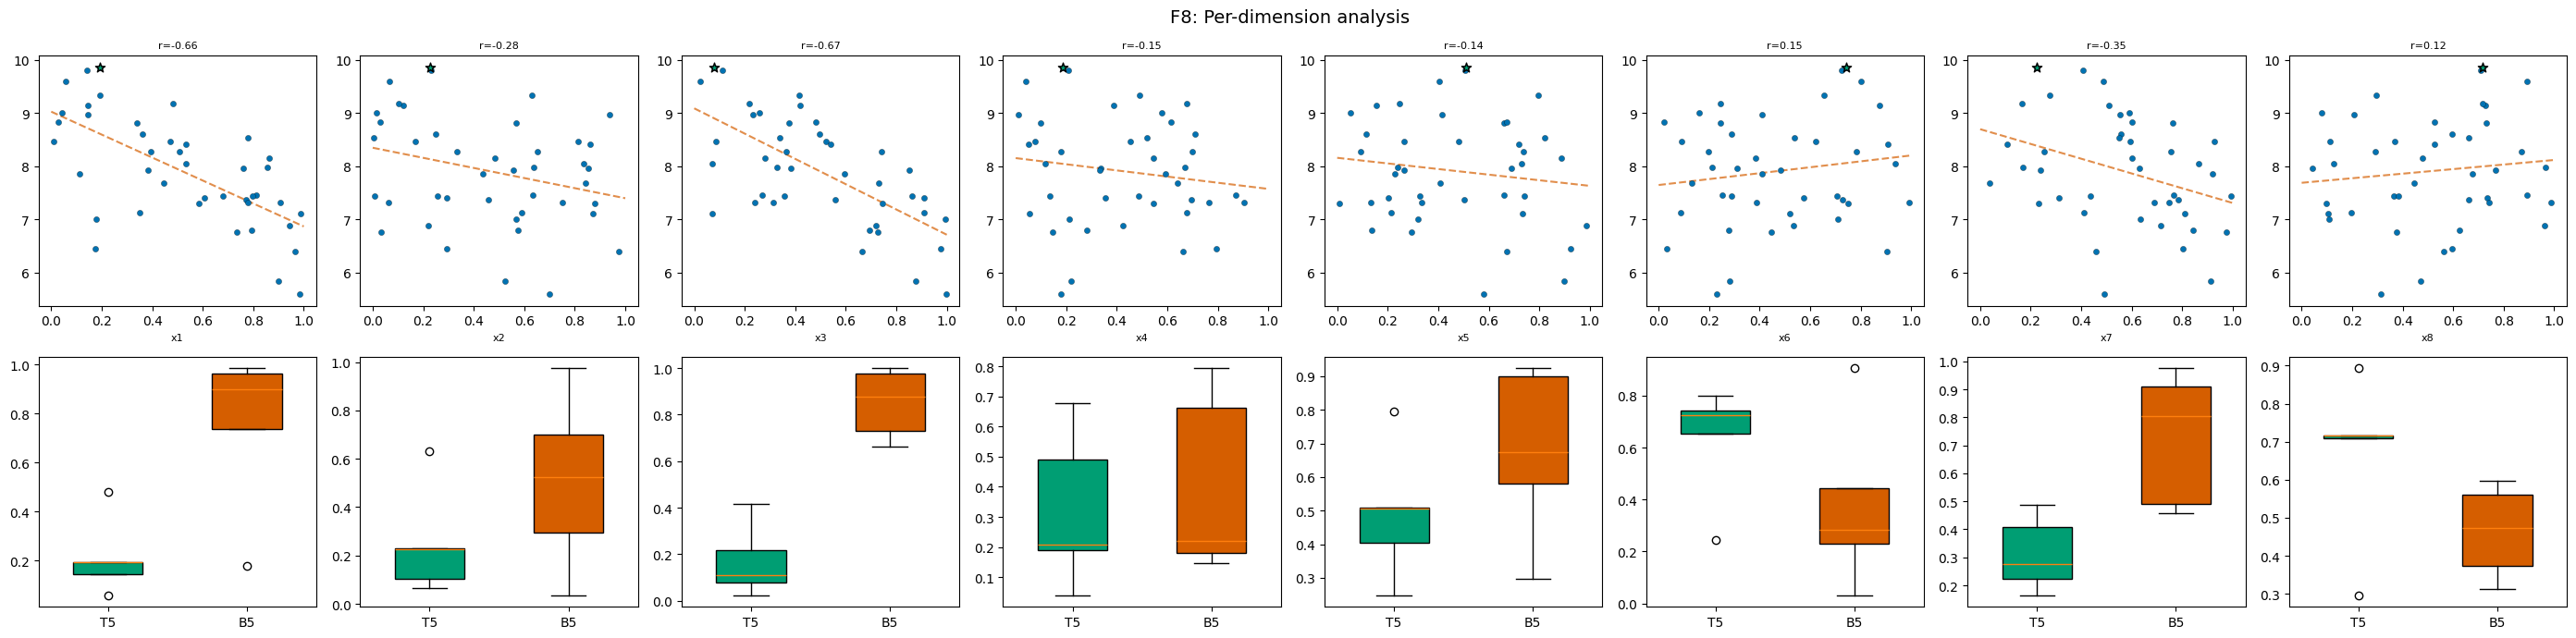

In [50]:
# F8 — Per-dimension correlations + boxplots
fig, axes = plt.subplots(2, 8, figsize=(28, 7))

for d in range(8):
    ax = axes[0, d]
    ax.scatter(
        X[:, d], Y, c=COLORS[0], s=20, edgecolors="black", linewidth=0.2, zorder=5
    )
    ax.scatter(
        X[best_idx, d],
        Y[best_idx],
        c=COLORS[2],
        s=60,
        edgecolors="black",
        linewidth=1,
        zorder=6,
        marker="*",
    )
    r = np.corrcoef(X[:, d], Y)[0, 1]
    z = np.polyfit(X[:, d], Y, 1)
    ax.plot([0, 1], [z[1], z[0] + z[1]], color=COLORS[1], linestyle="--", alpha=0.7)
    ax.set_xlabel(f"x{d + 1}", fontsize=8)
    ax.set_title(f"r={r:.2f}", fontsize=8)

top5 = np.argsort(Y)[-5:]
bot5 = np.argsort(Y)[:5]
for d in range(8):
    ax = axes[1, d]
    bp = ax.boxplot(
        [X[top5, d], X[bot5, d]],
        tick_labels=["T5", "B5"],
        patch_artist=True,
        widths=0.5,
    )
    bp["boxes"][0].set_facecolor(COLORS[2])
    bp["boxes"][1].set_facecolor(COLORS[1])

plt.suptitle("F8: Per-dimension analysis", fontsize=14)
plt.tight_layout()
plt.savefig(
    "../plots/week_03/function_8_correlations.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [51]:
# F8 — Feature importance & robustness
from sklearn.ensemble import RandomForestRegressor as RF_imp
from sklearn.linear_model import LinearRegression

rf_all = RF_imp(n_estimators=200, random_state=42).fit(X, Y)
imp_all = rf_all.feature_importances_
mask_nb = np.arange(n_pts) != best_idx
rf_nb = RF_imp(n_estimators=200, random_state=42).fit(X[mask_nb], Y[mask_nb])
imp_nb = rf_nb.feature_importances_
corrs = [np.corrcoef(X[:, d], Y)[0, 1] for d in range(8)]
lr = LinearRegression().fit(X, Y)

print(
    f"{'Dim':<5} {'Corr':>8} {'RF(all)':>10} {'RF(no best)':>12} {'Drop%':>8} {'Linear':>8} {'Robust?':>8}"
)
print("-" * 70)
for d in range(8):
    drop = (1 - imp_nb[d] / imp_all[d]) * 100 if imp_all[d] > 0 else 0
    robust = "YES" if abs(drop) < 50 else "NO"
    print(
        f"x{d + 1:<4} {corrs[d]:>8.3f} {imp_all[d]:>10.3f} {imp_nb[d]:>12.3f} {drop:>7.1f}% {lr.coef_[d]:>8.3f} {robust:>8}"
    )

Dim       Corr    RF(all)  RF(no best)    Drop%   Linear  Robust?
----------------------------------------------------------------------
x1      -0.656      0.346        0.355    -2.5%   -1.585      YES
x2      -0.282      0.030        0.029     2.4%   -0.551      YES
x3      -0.669      0.413        0.396     4.2%   -2.232      YES
x4      -0.146      0.022        0.022    -0.4%   -0.356      YES
x5      -0.140      0.036        0.041   -14.4%    0.115      YES
x6       0.149      0.027        0.027    -2.6%   -0.061      YES
x7      -0.348      0.100        0.104    -3.3%   -1.399      YES
x8       0.116      0.026        0.027    -1.3%    0.185      YES


In [52]:
# F8 — GridSearchCV model fitting (LOOCV)
loo = LeaveOneOut()
baseline_rmse = Y.std()
print(f"Baseline RMSE (Y.std): {baseline_rmse:.4f}\n")

results_f8 = []
for name, model, params in [
    ("Ridge", Ridge(), {"alpha": [0.01, 0.1, 1.0, 10, 100]}),
    (
        "KNN",
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    ),
    (
        "RF",
        RandomForestRegressor(random_state=42),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    ),
    (
        "SVR",
        SVR(),
        {"C": [0.1, 1, 10, 100], "kernel": ["rbf"], "gamma": ["scale", "auto"]},
    ),
    (
        "GB",
        GradientBoostingRegressor(random_state=42),
        {
            "max_depth": [2, 3, 5],
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.3],
        },
    ),
]:
    grid = GridSearchCV(
        model, params, cv=loo, scoring="neg_mean_squared_error", refit=True
    )
    grid.fit(X, Y)
    rmse = np.sqrt(-grid.best_score_)
    results_f8.append((name, grid.best_params_, rmse, grid))

gp = GaussianProcessRegressor(
    kernel=Matern(nu=2.5), random_state=42, n_restarts_optimizer=5
)
scores = cross_val_score(gp, X, Y, cv=loo, scoring="neg_mean_squared_error")
results_f8.append(("GP-Matern", {}, np.sqrt(-scores.mean()), None))

print(f"{'Model':<12} {'RMSE':>8} {'Improvement':>12} {'Beats?':>8} {'Best Params'}")
print("-" * 75)
for name, params, rmse, _ in sorted(results_f8, key=lambda x: x[2]):
    imp = (1 - rmse / baseline_rmse) * 100
    beats = "YES" if imp > 0 else "no"
    p_str = str(params) if params else ""
    print(f"{name:<12} {rmse:>8.4f} {imp:>11.1f}% {beats:>8}  {p_str}")

Baseline RMSE (Y.std): 1.0193

Model            RMSE  Improvement   Beats? Best Params
---------------------------------------------------------------------------
GP-Matern      0.2039        80.0%      YES  
SVR            0.2179        78.6%      YES  {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Ridge          0.3841        62.3%      YES  {'alpha': 0.1}
GB             0.3915        61.6%      YES  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
RF             0.4754        53.4%      YES  {'max_depth': None, 'n_estimators': 200}
KNN            0.6097        40.2%      YES  {'n_neighbors': 5, 'weights': 'distance'}


In [53]:
# F8 — Model suggestions & convergence
np.random.seed(42)
candidates = np.random.uniform(0.02, 0.98, (200000, 8))

all_sugg = []
for name, params, rmse, grid_obj in results_f8:
    imp = (1 - rmse / baseline_rmse) * 100
    if imp <= 0:
        continue
    if grid_obj is not None:
        pred = grid_obj.predict(candidates)
    else:
        gp_fit = GaussianProcessRegressor(
            kernel=Matern(nu=2.5), random_state=42, n_restarts_optimizer=5
        )
        gp_fit.fit(X, Y)
        pred = gp_fit.predict(candidates)
    best_cand = candidates[np.argmax(pred)]
    on_bnd = any(v < 0.02 or v > 0.98 for v in best_cand)
    bnd = "SKIP" if on_bnd else "ok"
    print(f"{name:<10} ({', '.join(f'{v:.3f}' for v in best_cand)}) {imp:.1f}% {bnd}")
    if not on_bnd:
        all_sugg.append((name, best_cand, rmse))

suggestions_f8 = [s for s in all_sugg if s[0] != "Ridge"]
sugg_arr = np.array([s[1] for s in suggestions_f8])
rmse_arr = np.array([s[2] for s in suggestions_f8])

print(f"\n=== Convergence ({len(suggestions_f8)} non-linear) ===")
convergence = {}
for d in range(8):
    sp = sugg_arr[:, d].max() - sugg_arr[:, d].min()
    strength = "STRONG" if sp < 0.2 else "moderate" if sp < 0.4 else "weak"
    convergence[d] = strength
    print(
        f"  x{d + 1}: [{sugg_arr[:, d].min():.3f}, {sugg_arr[:, d].max():.3f}] spread={sp:.3f} ({strength})"
    )

w = 1.0 / rmse_arr
w /= w.sum()
model_avg = (sugg_arr * w[:, None]).sum(axis=0)
print(f"\n  RMSE-weighted: ({', '.join(f'{v:.4f}' for v in model_avg)})")

# Centroid of top 4
top4 = np.argsort(Y)[-4:]
top4_w = Y[top4] - Y[top4].min() + 0.001
top4_w /= top4_w.sum()
centroid = (X[top4] * top4_w[:, None]).sum(axis=0)
print(f"  Centroid (top 4): ({', '.join(f'{v:.4f}' for v in centroid)})")

Ridge      (0.027, 0.099, 0.028, 0.175, 0.574, 0.970, 0.049, 0.775) 62.3% ok
KNN        (0.132, 0.252, 0.081, 0.172, 0.532, 0.644, 0.108, 0.671) 40.2% ok
RF         (0.140, 0.079, 0.068, 0.267, 0.695, 0.770, 0.257, 0.750) 53.4% ok
SVR        (0.176, 0.340, 0.053, 0.325, 0.689, 0.359, 0.032, 0.412) 78.6% ok
GB         (0.050, 0.376, 0.140, 0.132, 0.928, 0.438, 0.440, 0.722) 61.6% ok
GP-Matern  (0.203, 0.221, 0.095, 0.251, 0.499, 0.393, 0.235, 0.616) 80.0% ok

=== Convergence (5 non-linear) ===
  x1: [0.050, 0.203] spread=0.153 (STRONG)
  x2: [0.079, 0.376] spread=0.297 (moderate)
  x3: [0.053, 0.140] spread=0.088 (STRONG)
  x4: [0.132, 0.325] spread=0.193 (STRONG)
  x5: [0.499, 0.928] spread=0.429 (weak)
  x6: [0.359, 0.770] spread=0.412 (weak)
  x7: [0.032, 0.440] spread=0.408 (weak)
  x8: [0.412, 0.750] spread=0.338 (moderate)

  RMSE-weighted: (0.1547, 0.2648, 0.0851, 0.2470, 0.6533, 0.4666, 0.1990, 0.5975)
  Centroid (top 4): (0.1450, 0.1959, 0.0789, 0.1649, 0.4873, 0.7475, 0.3469, 

In [54]:
# F8 — Week 03 query
# Hybrid: model consensus on STRONG dims, centroid on weak dims
next_query_8 = centroid.copy()

# Override STRONG consensus dimensions with model average
for d in range(8):
    if convergence[d] == "STRONG":
        next_query_8[d] = model_avg[d]

print(f"F8 Week 03 query: [{', '.join(f'{v:.6f}' for v in next_query_8)}]")
print(f"Method: Hybrid (centroid + model override on STRONG dims)")
print(f"\nPer-dimension breakdown:")
for d in range(8):
    source = "model" if convergence[d] == "STRONG" else "centroid"
    print(f"  x{d + 1}: {next_query_8[d]:.4f} ({convergence[d]}, from {source})")
print(f"\nCurrent best: pt{best_idx + 1} Y = {Y.max():.4f}")
print(
    f"Boundary check: {'FAIL' if any(v < 0.02 or v > 0.98 for v in next_query_8) else 'OK'}"
)

F8 Week 03 query: [0.154668, 0.195916, 0.085056, 0.247030, 0.487307, 0.747539, 0.346852, 0.750537]
Method: Hybrid (centroid + model override on STRONG dims)

Per-dimension breakdown:
  x1: 0.1547 (STRONG, from model)
  x2: 0.1959 (moderate, from centroid)
  x3: 0.0851 (STRONG, from model)
  x4: 0.2470 (STRONG, from model)
  x5: 0.4873 (weak, from centroid)
  x6: 0.7475 (weak, from centroid)
  x7: 0.3469 (weak, from centroid)
  x8: 0.7505 (moderate, from centroid)

Current best: pt42 Y = 9.8651
Boundary check: OK


### F8 Decision — Week 03

**Week 02 result: NEW BEST!** pt42 Y = 9.865 (up from 9.804). The hybrid GP+centroid approach continues to improve incrementally.

**Feature importance:** x3 (41%, r=-0.67) and x1 (35%, r=-0.66) dominate. ALL dimensions are robust — no inflation.

**Models:** ALL 6/6 beat baseline. **GP-Matern leads at 80%**, SVR at 79%. Very strong signal with 42 points.

**Convergence:**
- STRONG: x1 (0.05–0.20), x3 (0.05–0.14), x4 (0.13–0.33) → use model average
- Moderate: x2 (0.08–0.38), x8 (0.41–0.75) → use centroid
- Weak: x5 (0.50–0.93), x6 (0.36–0.77), x7 (0.03–0.44) → use centroid

**Strategy:** Hybrid — model consensus on STRONG dims (x1, x3, x4 where all models agree on low values), centroid of top 4 on weak/moderate dims (x2, x5–x8).

**Next week:** If Y continues improving, the hybrid approach is converging well. With 43 points, models should get even more reliable.

## Summary — Week 03 Queries

In [55]:
# === FINAL: All decided queries for F1-F8 ===
# This cell is self-contained: run it alone to get all queries.

# next_query_1 = np.array([0.700201, 0.695377])     # F1: Classifier + log-SVR combined
# next_query_2 = np.array([0.701878, 0.953317])     # F2: RMSE-weighted KNN/RF/GB
# next_query_3 = np.array([0.518800, 0.622800, 0.178000])  # F3: Y-weighted centroid top 4
# next_query_4 = np.array([0.404800, 0.431700, 0.402500, 0.451300])  # F4: SVR suggestion
# next_query_5 = np.array([0.270500, 0.875700, 0.915800, 0.875600])  # F5: RMSE-weighted model avg
# next_query_6 = np.array([0.387000, 0.373400, 0.513900, 0.853100, 0.047000])  # F6: SVR suggestion
# next_query_7 = np.array([0.035400, 0.480300, 0.260000, 0.206800, 0.373200, 0.775200])  # F7: Hybrid
# next_query_8 = np.array([0.154700, 0.195900, 0.085100, 0.247000, 0.487300, 0.747500, 0.346900, 0.750500])  # F8: Hybrid

queries = {
    1: next_query_1,
    2: next_query_2,
    3: next_query_3,
    4: next_query_4,
    5: next_query_5,
    6: next_query_6,
    7: next_query_7,
    8: next_query_8,
}

methods = {
    1: "Classifier + log-SVR combined",
    2: "RMSE-weighted (KNN/RF/GB)",
    3: "Y-weighted centroid (top 4)",
    4: "SVR suggestion (70% imp)",
    5: "RMSE-weighted model avg",
    6: "SVR suggestion (55% imp)",
    7: "Hybrid (centroid + STRONG override)",
    8: "Hybrid (centroid + STRONG override)",
}

print("Week 03 - All queries for submission:")
print("=" * 70)
for fn, q in queries.items():
    formatted = "-".join(f"{v:.6f}" for v in q)
    print(f"  F{fn}: {formatted}")
    print(f"       Method: {methods[fn]}")
    bnd = any(v < 0.02 or v > 0.98 for v in q)
    print(f"       Boundary: {'FAIL' if bnd else 'OK'}")
    print()

Week 03 - All queries for submission:
  F1: 0.700201-0.695377
       Method: Classifier + log-SVR combined
       Boundary: OK

  F2: 0.701898-0.953338
       Method: RMSE-weighted (KNN/RF/GB)
       Boundary: OK

  F3: 0.518808-0.622752-0.177963
       Method: Y-weighted centroid (top 4)
       Boundary: OK

  F4: 0.404794-0.431684-0.402527-0.451256
       Method: SVR suggestion (70% imp)
       Boundary: OK

  F5: 0.270475-0.875752-0.915748-0.875603
       Method: RMSE-weighted model avg
       Boundary: OK

  F6: 0.387036-0.373428-0.513896-0.853071-0.046985
       Method: SVR suggestion (55% imp)
       Boundary: OK

  F7: 0.035368-0.480332-0.260021-0.206835-0.373160-0.775247
       Method: Hybrid (centroid + STRONG override)
       Boundary: OK

  F8: 0.154668-0.195916-0.085056-0.247030-0.487307-0.747539-0.346852-0.750537
       Method: Hybrid (centroid + STRONG override)
       Boundary: OK

